# **===========================================================================================================================================================** #
# **Incremental Capstone 8 - Movies** #
# **===========================================================================================================================================================** #

In [246]:
#Import Statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.base import (
    BaseEstimator, 
    TransformerMixin
)

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    mean_squared_error, 
    root_mean_squared_error, 
    r2_score,
    silhouette_score,
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    classification_report,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    KBinsDiscretizer,
    PowerTransformer,
    QuantileTransformer,
    MinMaxScaler,
    StandardScaler,
    FunctionTransformer,
    OrdinalEncoder,
    OneHotEncoder,
    LabelEncoder,
    PolynomialFeatures
)

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression,
    Ridge, 
    Lasso,
    ElasticNet
)

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering, 
    FeatureAgglomeration,
    DBSCAN
)

from sklearn.model_selection import(
    train_test_split,
    GridSearchCV,
    cross_val_score,
    KFold
)

from scipy.stats import t
from scipy.stats import (
    boxcox, 
    yeojohnson, 
    shapiro
)

from scipy.cluster.hierarchy import (
    dendrogram, 
    linkage
)

import scipy.sparse as sp
from scipy.sparse.linalg import svds

from sklearn.impute import (
    SimpleImputer,
    KNNImputer
)

from sklearn.metrics.pairwise import (
    cosine_similarity
)

from sklearn.decomposition import (
    PCA,
    TruncatedSVD,
    NMF
)

from sklearn.manifold import TSNE

from statsmodels.nonparametric.smoothers_lowess import lowess

from kneed import KneeLocator

### **EDA Utility Functions** ###

In [247]:

data_set_name = ''
target_label = ''

def WrapText(text, max_width=15):
    """Wrap text to multiple lines"""
    words = str(text).split()
    lines = []
    current_line = ""
    
    for word in words:
        if len(current_line + " " + word) <= max_width:
            current_line = (current_line + " " + word).strip()
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    
    return "\n".join(lines)

def DisplayTable(df_target, table_title=None, max_cell_length=30, show_index=False, 
                 wrap_headers=True, header_wrap_width=15, min_height=3,
                 row_height=0.35, font_size=10):

    if df_target.empty:
        print(f"No data to display{': ' + table_title if table_title else ''}")
        return

    n_rows, n_cols = df_target.shape
    
    # Adjust columns if showing index
    if show_index:
        n_cols += 1

    # Calculate width based on longest column name or cell content
    col_widths = []
    for col in df_target.columns:
        if wrap_headers:
            max_len = max(len(line) for line in WrapText(col, header_wrap_width).split('\n'))
        else:
            max_len = len(str(col))
        for val in df_target[col]:
            val_len = len(f"{val:.2f}" if isinstance(val, float) else str(val))
            max_len = max(max_len, val_len)
        col_widths.append(min(max_len, max_cell_length))
    
    # Dynamic figure width based on content
    fig_width = max(sum(col_widths) * 0.15, n_cols * 2.0)
    
    # Calculate extra height for wrapped headers
    if wrap_headers:
        max_header_lines = max(len(WrapText(col, header_wrap_width).split('\n')) for col in df_target.columns)
    else:
        max_header_lines = 1
    
    fig_height = (n_rows + max_header_lines) * row_height
    if table_title:
        fig_height += 0.4
    
    # Ensure minimum height for small tables
    fig_height = max(fig_height, min_height)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Format floats and truncate long text
    cell_text = []
    for idx, row in zip(df_target.index, df_target.values):
        new_row = []
        
        # Add index as first column if show_index
        if show_index:
            s = str(idx)
            if len(s) > max_cell_length:
                s = s[:max_cell_length - 3] + '...'
            new_row.append(s)
        
        for val in row:
            if isinstance(val, (float)) and not isinstance(val, bool):
                new_row.append(f"{val:.2f}")
            else:
                s = str(val)
                if len(s) > max_cell_length:
                    s = s[:max_cell_length - 3] + '...'
                new_row.append(s)
        cell_text.append(new_row)

    # Build column labels (with wrapping)
    if show_index:
        col_labels = [df_target.index.name or '']
        if wrap_headers:
            col_labels += [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels += list(df_target.columns)
    else:
        if wrap_headers:
            col_labels = [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels = list(df_target.columns)

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='upper center',
        bbox=[0, 0, 1, 1]
    )

    # Bold column headers and set header background
    for col in range(n_cols):
        table[(0, col)].set_facecolor('#4a90d9')
        table[(0, col)].set_text_props(color='white', fontweight='bold')

    # Style data cells
    for row in range(1, n_rows + 1):
        for col in range(n_cols):
            if show_index and col == 0:
                table[(row, col)].set_facecolor('#b8d4e8')
                table[(row, col)].set_text_props(fontweight='bold')
            else:
                table[(row, col)].set_facecolor('#d4e6f1')

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.auto_set_column_width(col=list(range(n_cols)))

    if table_title is not None:
        fig.suptitle(table_title, fontweight='bold', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95] if table_title else [0, 0, 1, 1])

    plt.show()
    plt.close(fig)
    print()
    print()
    
def PrintDataFrameStatistics(df_target, display_table=True):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()

    # Capture for Table plot
    df_stats = df_target.describe(include='all').T.reset_index()
    df_stats.rename(columns={'index': 'Feature'}, inplace=True)
    print(df_stats)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()

    df_info = pd.DataFrame({
                            'Feature': df_target.columns,
                            'Non-Null Count': df_target.notna().sum().values,
                            'Null Count': df_target.isna().sum().values,
                            'Dtype': df_target.dtypes.values
                            }).reset_index(drop=True)

    print(f'Dataset Shape:{df_target.shape}')
    df_shape = pd.DataFrame({'Rows': [df_target.shape[0]], 'Columns': [df_target.shape[1]]})
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Do we have any features empty strings?:')
    print((df_target == "").any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])

    # Capture for Table plot
    cols_to_plot = df_target.select_dtypes(exclude=['number']).columns
    missing = df_target[cols_to_plot].isnull().sum()
    missing = missing[missing > 0]
    df_missing = pd.DataFrame({
                                'Feature': missing.index,
                                'Missing Count': missing.values,
                                'Missing %': (missing.values / len(df_target) * 100).round(2)
                                }).reset_index(drop=True)
    print()

    print('Do we have any features with nan values?:')

    cols_to_plot = df_target.select_dtypes(include=['number']).columns
    nan_vals = df_target[cols_to_plot].isna().sum()
    nan_vals = nan_vals[nan_vals > 0]
    # Capture for Table plot
    df_nan = pd.DataFrame({
                            'Feature': nan_vals.index,
                            'NaN Count': nan_vals.values,
                            'NaN %': (nan_vals.values / len(df_target) * 100).round(2)
                        }).reset_index(drop=True)
    print(df_target.isna().any().any())

    # Sum up the number of missing features per row
    missing_per_row = df_target.isna().sum(axis=1)  # count missing per row
    missing_counts = missing_per_row.value_counts().sort_index()  # count rows for each missing count

    df_missingfeature_rowcounts = pd.DataFrame({
        'Missing Features': missing_counts.index,
        'Row Count': missing_counts.values
    })

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(df_target.head(20))
    print()

    print("***********************************")
    print("First 20 rows of Random Sample Data")
    print("***********************************")
    print()
    df_randomsample = df_target.sample(n=20)
    print(df_target.sample(20))
    print()

    #
    # Display Results in Pretty Tables
    #
    if display_table == True:
        print('Display Analysis Results in Tables')
        DisplayTable(df_stats, f'{data_set_name} Description Statistics')
        print()
        DisplayTable(df_info, f'{data_set_name} Basic Information')
        print()
        DisplayTable(df_shape, f'{data_set_name} Dataset Shape')
        print()
        DisplayTable(df_missing, f'{data_set_name} Missing Categorical (String) Data')
        print()
        DisplayTable(df_nan, f'{data_set_name} Missing Numeric Data')
        print()
        DisplayTable(df_missingfeature_rowcounts, f'{data_set_name} Summary of Missing Feature Row Counts')
        print()    
        DisplayTable(df_randomsample, f'{data_set_name} Random Data Sample')
        
    print()

### **Initial Data Load** ###

In [248]:
# Loading Movies and Ratings Data
df_Movies_Original = pd.read_csv('movies.csv')
df_Ratings_Original = pd.read_csv('ratings.csv')

# Make a copy of the dataframe to contain the modifications completed in this workbook
df_Movies = df_Movies_Original.copy(deep=True)
df_Ratings = df_Ratings_Original.copy(deep=True)

movie_data_set_name = 'Movies Data'
ratings_data_set_name = 'Ratings Data'
target_label = ''

## **1. Initial Exploratory Data Analysis** ##

Movie Data
***********************************
Description Stats
***********************************

   Feature   count unique              top  freq          mean           std  \
0  movieId  9742.0    NaN              NaN   NaN  42200.353623  52160.494854   
1    title    9742   9737  Saturn 3 (1980)     2           NaN           NaN   
2   genres    9742    951            Drama  1053           NaN           NaN   

   min      25%     50%      75%       max  
0  1.0  3248.25  7300.0  76232.0  193609.0  
1  NaN      NaN     NaN      NaN       NaN  
2  NaN      NaN     NaN      NaN       NaN  

***********************************
Basic Info of imported data set
***********************************

Dataset Shape:(9742, 3)

Do we have any features with null values?:
False

Do we have any features empty strings?:
movieId    False
title      False
genres     False
dtype: bool

Feature Columns with that have null values:
Series([], dtype: int64)

Do we have any features with nan values?:


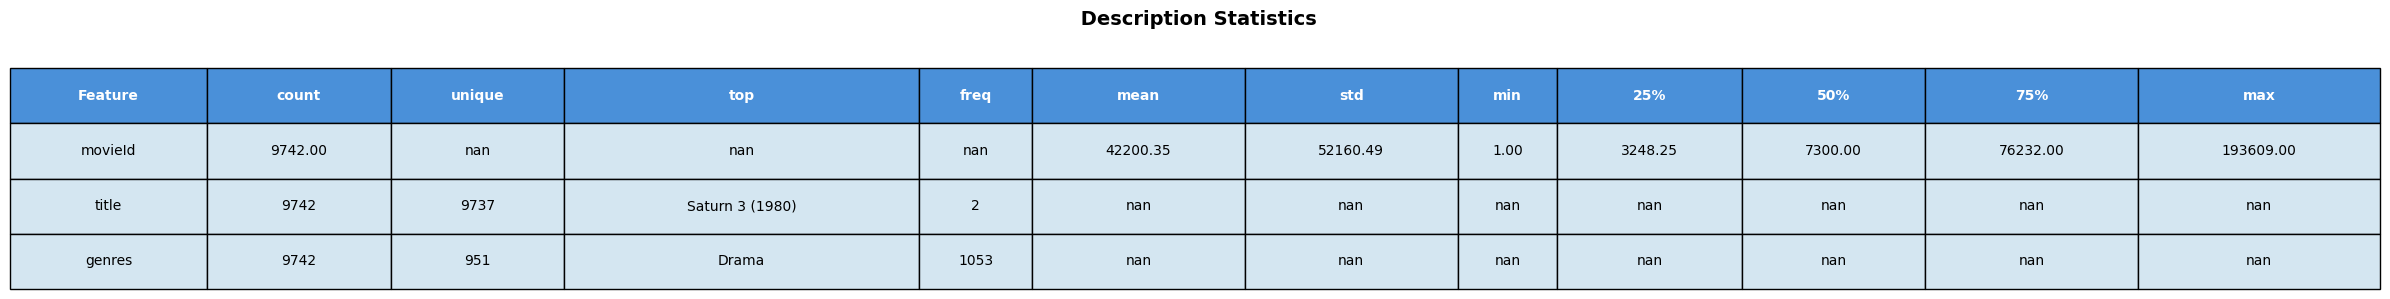

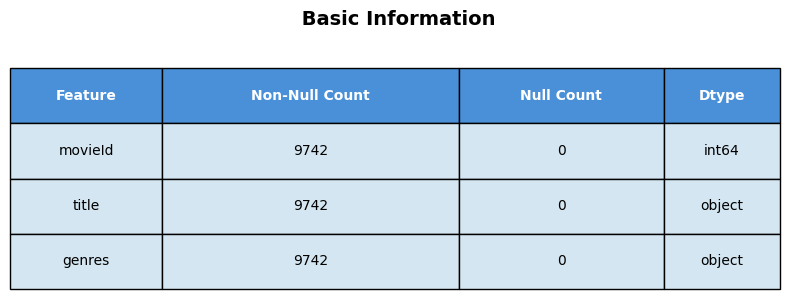

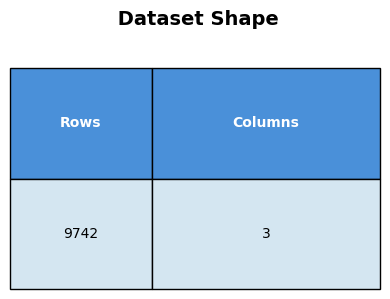




No data to display:  Missing Categorical (String) Data

No data to display:  Missing Numeric Data



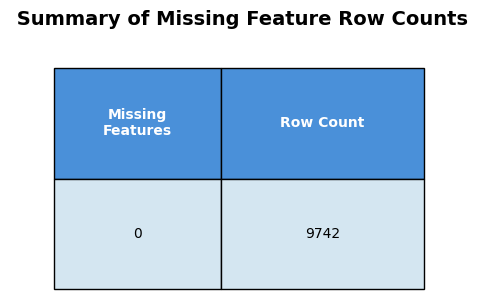

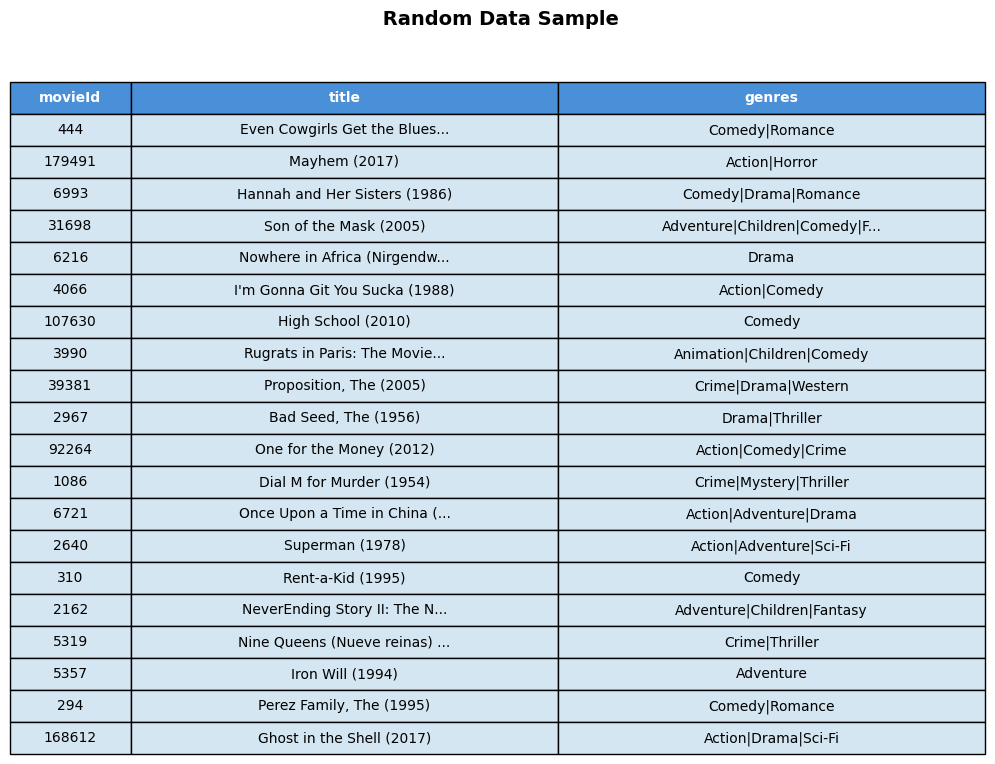




Ratings Data
***********************************
Description Stats
***********************************

     Feature     count          mean           std          min           25%  \
0     userId  100836.0  3.261276e+02  1.826185e+02          1.0  1.770000e+02   
1    movieId  100836.0  1.943530e+04  3.553099e+04          1.0  1.199000e+03   
2     rating  100836.0  3.501557e+00  1.042529e+00          0.5  3.000000e+00   
3  timestamp  100836.0  1.205946e+09  2.162610e+08  828124615.0  1.019124e+09   

            50%           75%           max  
0  3.250000e+02  4.770000e+02  6.100000e+02  
1  2.991000e+03  8.122000e+03  1.936090e+05  
2  3.500000e+00  4.000000e+00  5.000000e+00  
3  1.186087e+09  1.435994e+09  1.537799e+09  

***********************************
Basic Info of imported data set
***********************************

Dataset Shape:(100836, 4)

Do we have any features with null values?:
False

Do we have any features empty strings?:
userId       False
movieId      Fa

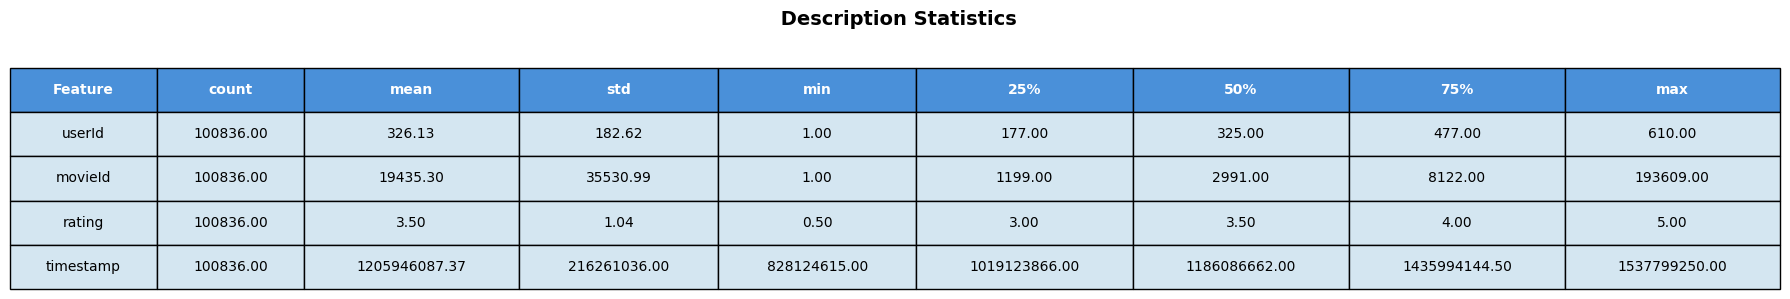

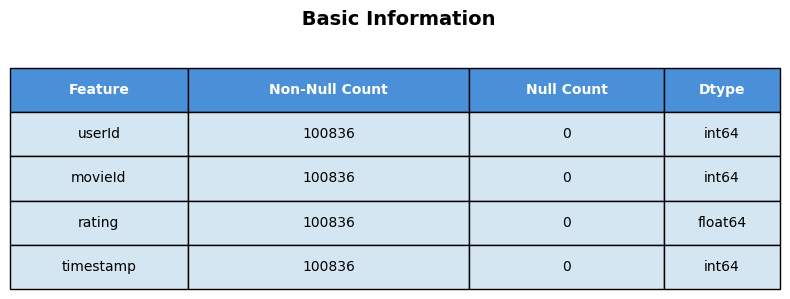

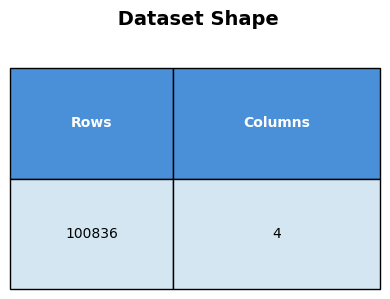




No data to display:  Missing Categorical (String) Data

No data to display:  Missing Numeric Data



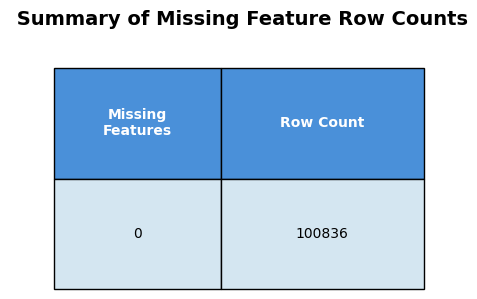

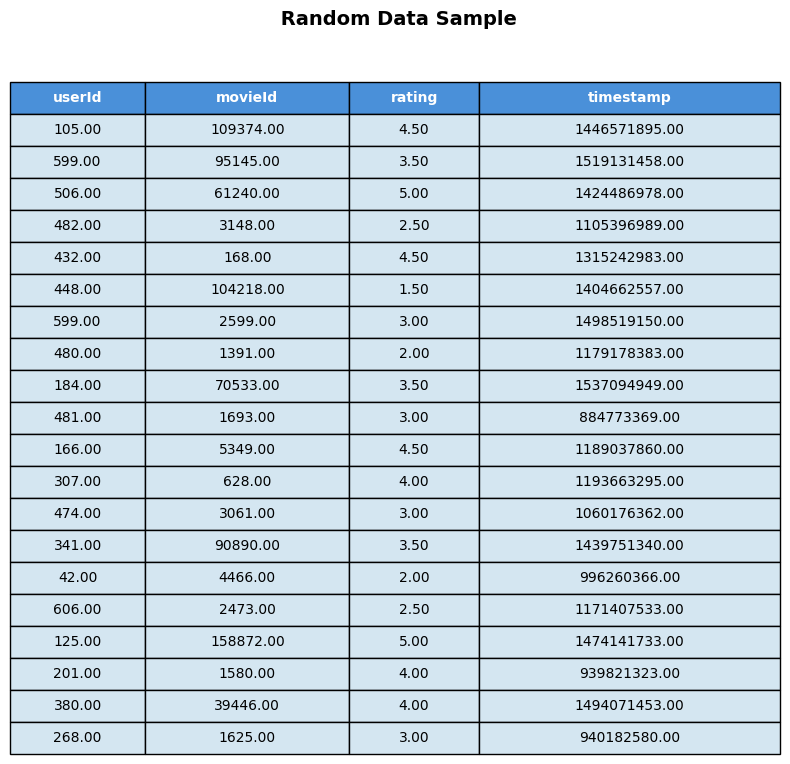

In [249]:
# print out the dataframes stats
print('Movie Data')
PrintDataFrameStatistics(df_Movies)

print('Ratings Data')
PrintDataFrameStatistics(df_Ratings)

### **Initial EDA Analysis** ###
    - Movie Data - 9742 rows of data, 3 features (columns)
    - Ratings Data - 100836 rows of data, 4 features (columns)
    - No rows of missing or (nan) data in either dataset
    - Need to leading/following trim() categorical feature columns

### **Missing Values and Imputation** ###
Not required

##### **Trim Categorical Features** #####

In [250]:
# Movie
obj_cols = df_Movies.select_dtypes(include='object').columns
df_Movies[obj_cols] = df_Movies[obj_cols].apply(lambda col: col.str.strip())

## **2. Data Wrangling and Feature Engineering** ##

### **New Feature Creation** ###
    - Initial examination of the Movie Dataset indicates we can
        - Split Title Feature into "Title" and "Year Released"
        - Split Genres into separate features using

Unique Movie Genres
Number of Unique Genres: (20, 2)


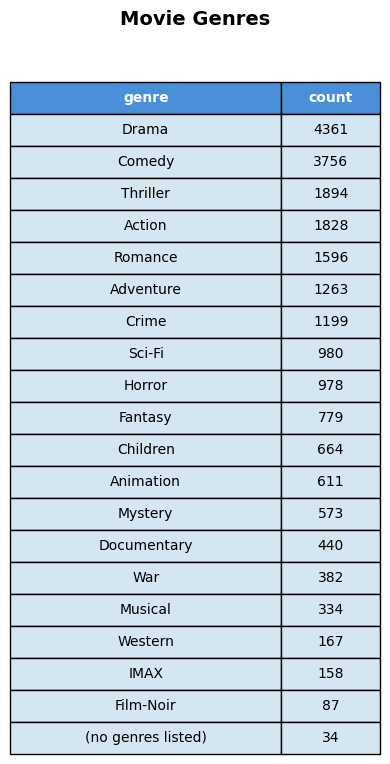

In [251]:
# Genres

# What are the unique genres in the dataset
print('Unique Movie Genres')
df_Genres = df_Movies['genres'].str.split('|').explode().value_counts().reset_index()
df_Genres.columns = ['genre', 'count']
df_Genres['count'] = df_Genres['count'].astype(int)

print(f'Number of Unique Genres: {df_Genres.shape}')
DisplayTable(df_Genres, table_title='Movie Genres')
print()

genres = df_Movies['genres'].str.get_dummies(sep='|')
df_Movies = pd.concat([df_Movies, df_Movies['genres'].str.get_dummies(sep='|')], axis=1)
df_Movies.drop('genres', axis=1, inplace=True)

# Title has the following format: "Movie Title (1999)"
# Title/Year Split - Regex Expressions is best solution
df_Movies['Year'] = df_Movies['title'].str.extract(r'\((\d{4})\)$')

# rsplit() - splits from right to left, so if Title contains (), we don't lose thems
df_Movies['Title'] = df_Movies['title'].str.replace(r'\s*\(\d{4}\)$', '', regex=True)
df_Movies.drop('title', axis=1, inplace=True)

#PrintDataFrameStatistics(df_Movies)

##### **Other interesting eatures we could create..** #####
    - Average Rating per user
    - Number of Ratings per user
    - Average Rating per Movie
    - Number of Ratings per Movie
    - Number of Genres per Movie 

### **Merge Movie and Ratings into Single DataFrame** ###

In [252]:
df_Merged = df_Movies.merge(df_Ratings, left_on='movieId', right_on='movieId')

# Rename column/featurs for consistency
df_Merged.rename(columns={'movieId': 'MovieId'}, inplace=True)
df_Merged.rename(columns={'userId': 'UserId'}, inplace=True)
df_Merged.rename(columns={'rating': 'Rating'}, inplace=True)

#PrintDataFrameStatistics(df_Merged)

#### **Convert timestamp Into Actual DateTime, Year, Month, Day, Hour** ####

***********************************
Description Stats
***********************************

               Feature     count unique           top   freq  \
0              MovieId  100836.0    NaN           NaN    NaN   
1   (no genres listed)  100836.0    NaN           NaN    NaN   
2               Action  100836.0    NaN           NaN    NaN   
3            Adventure  100836.0    NaN           NaN    NaN   
4            Animation  100836.0    NaN           NaN    NaN   
5             Children  100836.0    NaN           NaN    NaN   
6               Comedy  100836.0    NaN           NaN    NaN   
7                Crime  100836.0    NaN           NaN    NaN   
8          Documentary  100836.0    NaN           NaN    NaN   
9                Drama  100836.0    NaN           NaN    NaN   
10             Fantasy  100836.0    NaN           NaN    NaN   
11           Film-Noir  100836.0    NaN           NaN    NaN   
12              Horror  100836.0    NaN           NaN    NaN   
13           

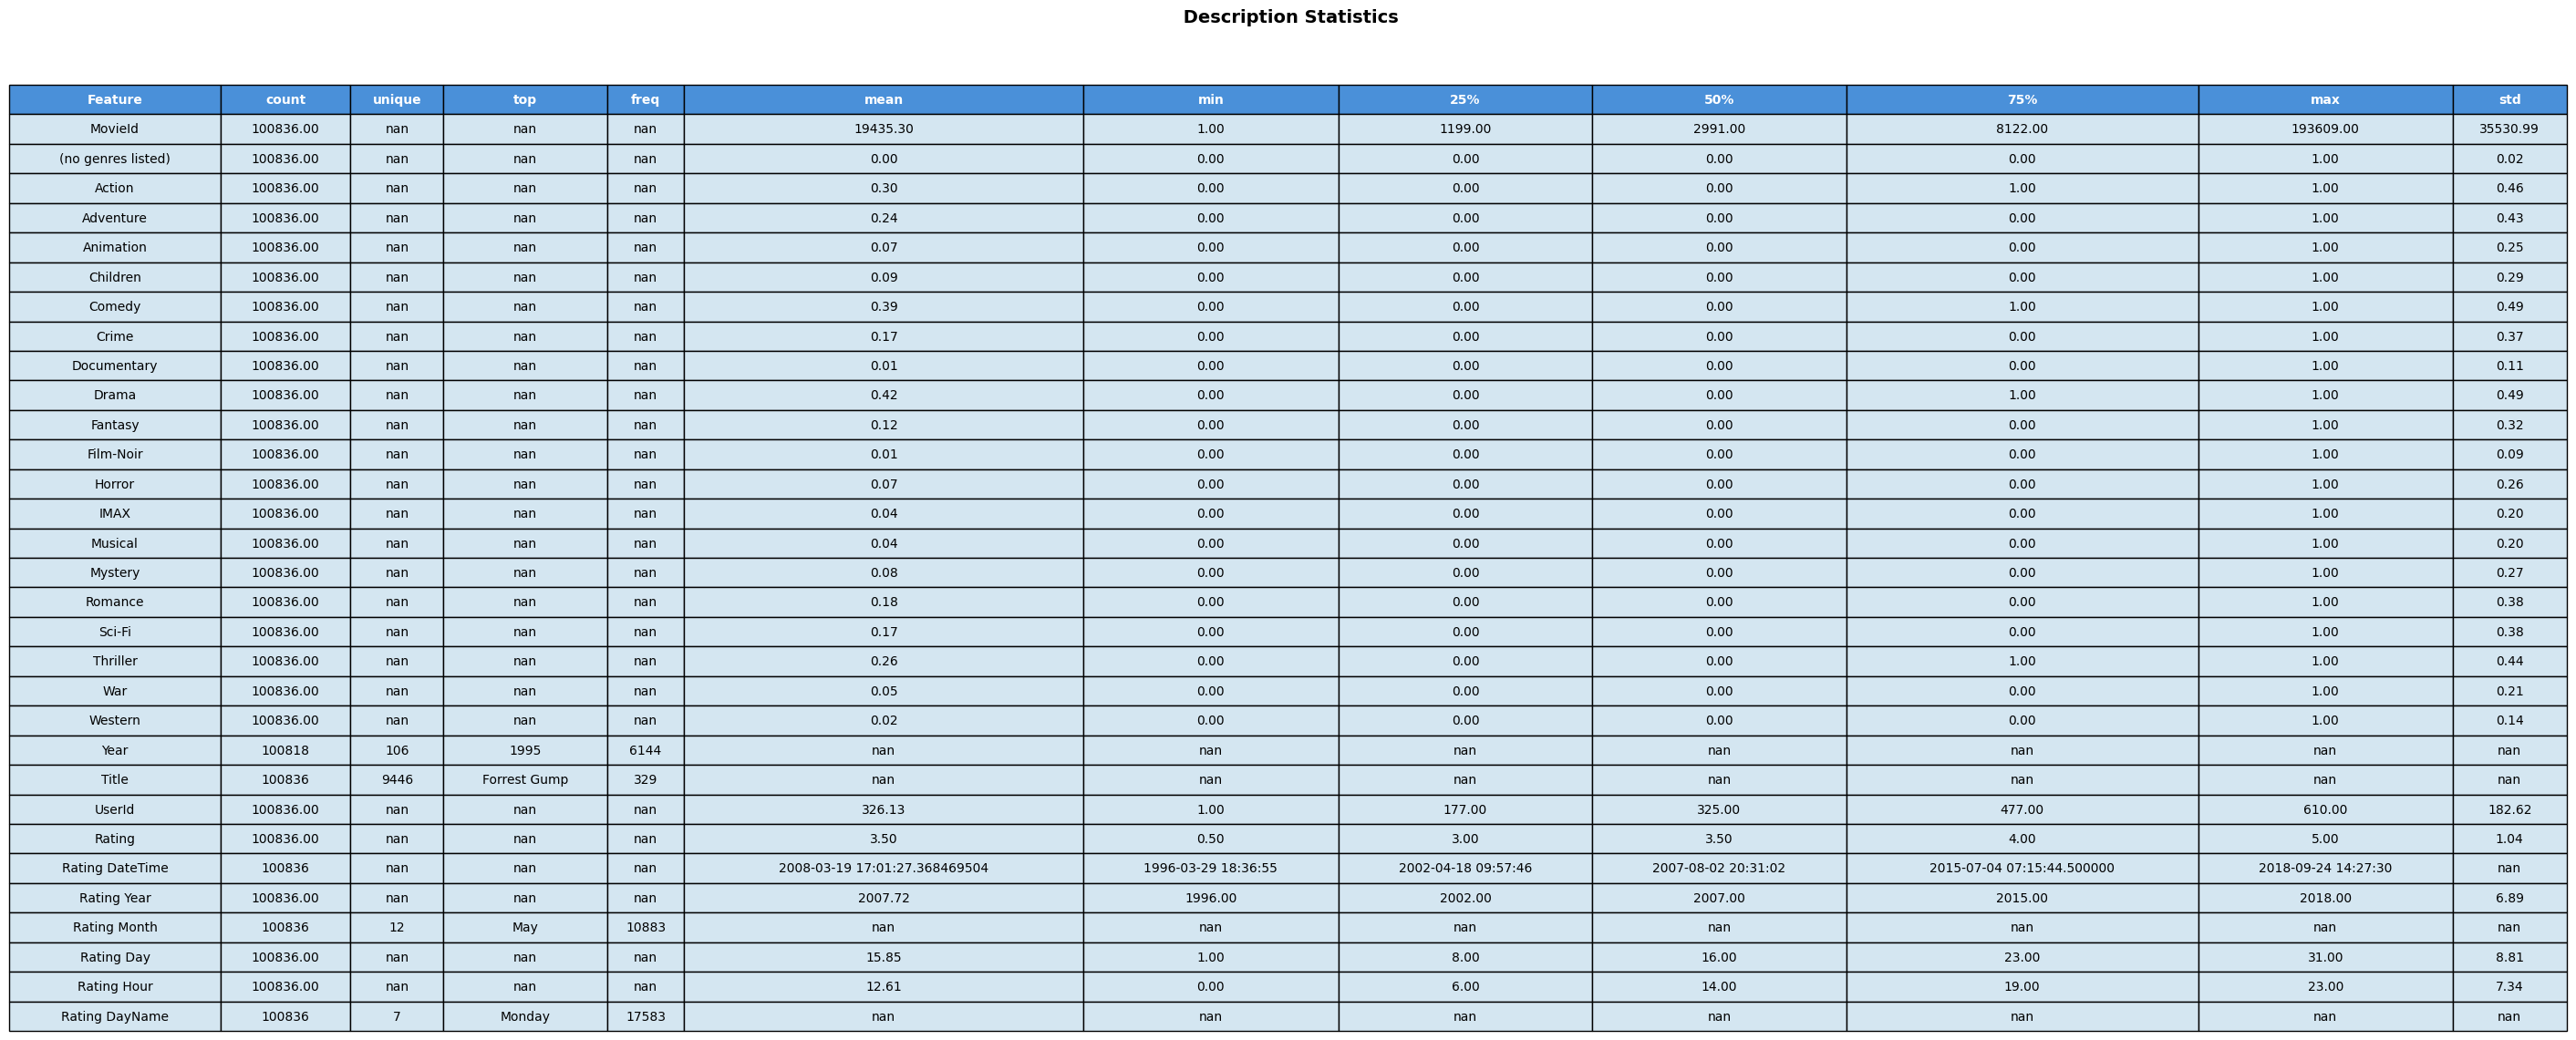

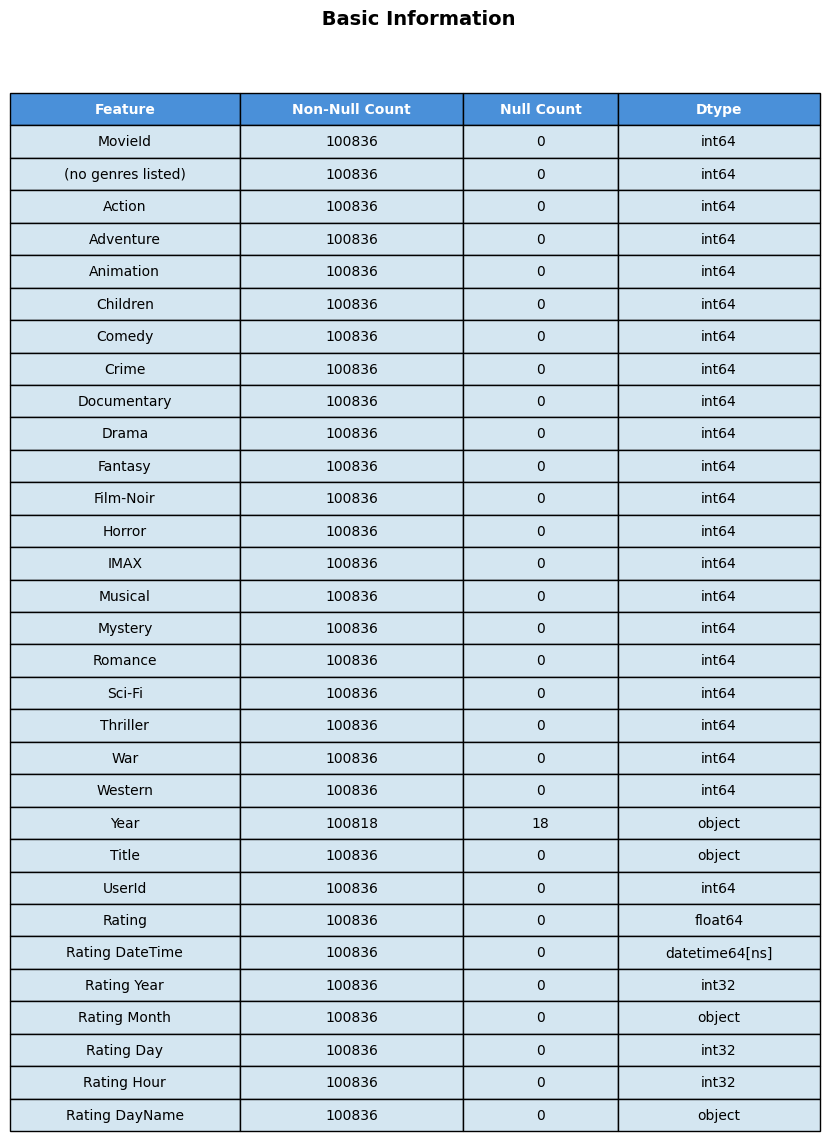

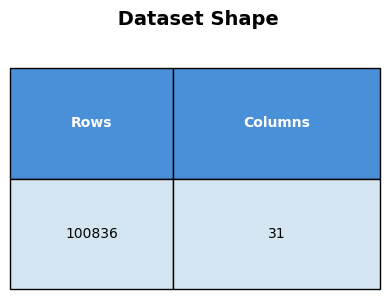

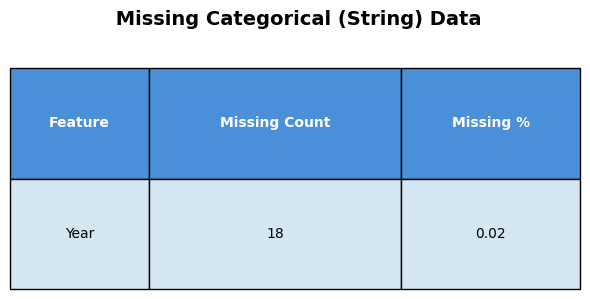




No data to display:  Missing Numeric Data



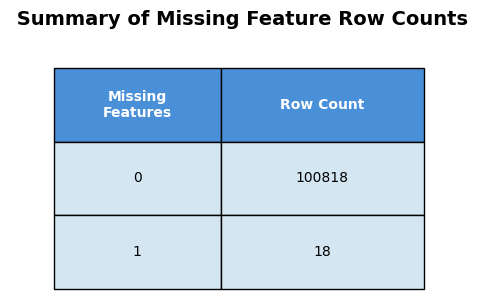

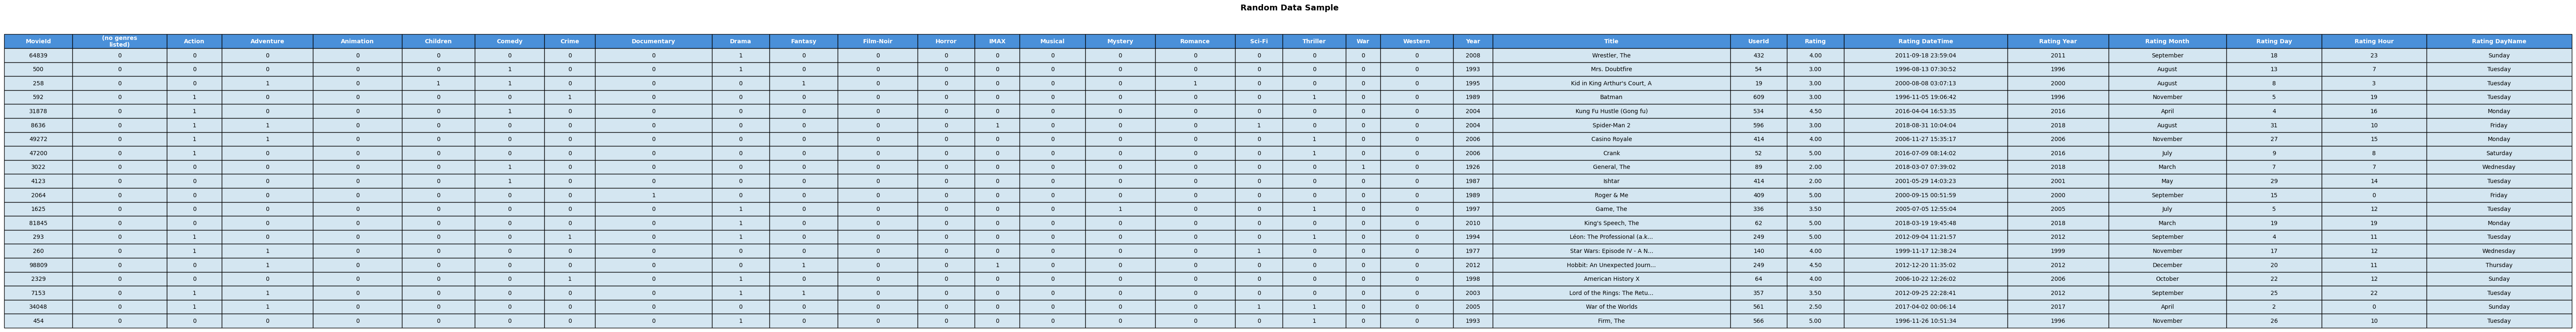

In [253]:
# Convert to DateTime
df_Merged['Rating DateTime'] = pd.to_datetime(df_Merged['timestamp'], unit='s')
df_Merged.drop('timestamp', axis=1, inplace=True)

df_Merged['Rating Year'] = df_Merged['Rating DateTime'].dt.year       
df_Merged['Rating Month'] = df_Merged['Rating DateTime'].dt.month_name()       
df_Merged['Rating Day'] = df_Merged['Rating DateTime'].dt.day         
df_Merged['Rating Hour'] = df_Merged['Rating DateTime'].dt.hour        
df_Merged['Rating DayName'] = df_Merged['Rating DateTime'].dt.day_name()  


PrintDataFrameStatistics(df_Merged)

### **Data Type Conversion** ###
    - For OS memory performance and model efficiency, convert to more efficient data types.

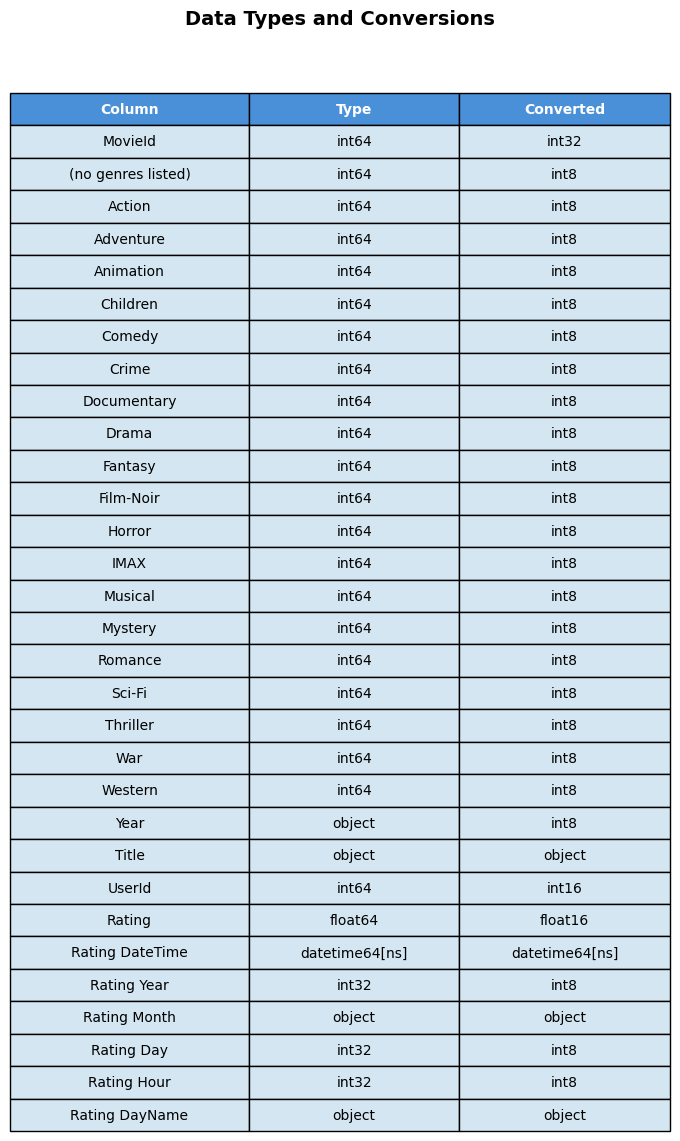




Converted Data Columns


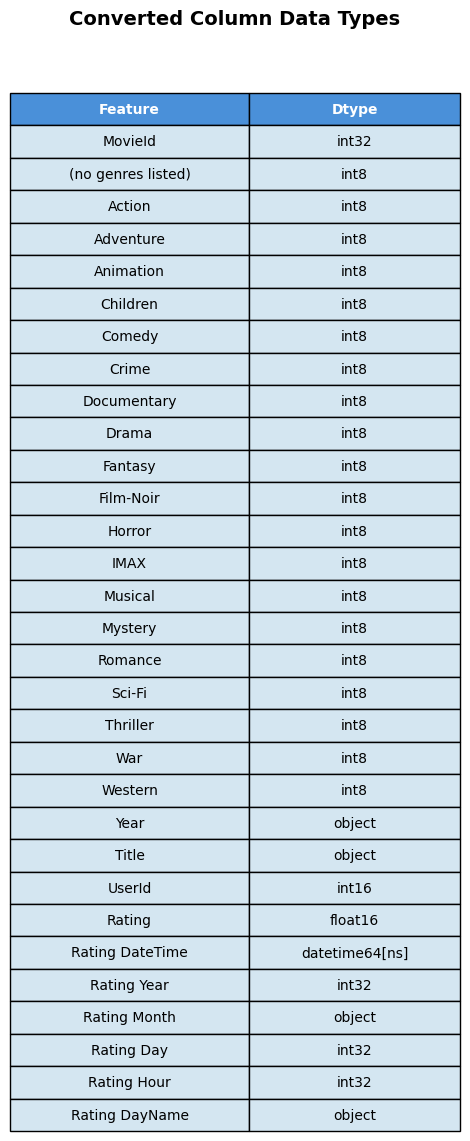

In [254]:
#print(df_Merged.dtypes)


# Features, Types and Data Type Conversion Targets..
df_types = pd.DataFrame({
                    'Column': [
                        'MovieId', '(no genres listed)', 'Action', 'Adventure', 'Animation', 
                        'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 
                        'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 
                        'Sci-Fi', 'Thriller', 'War', 'Western', 'Year', 'Title', 'UserId', 
                        'Rating', 'Rating DateTime', 'Rating Year', 'Rating Month', 
                        'Rating Day', 'Rating Hour', 'Rating DayName'
                    ],
                    'Type': [
                        'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 
                        'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 
                        'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 
                        'object', 'object', 'int64', 'float64', 'datetime64[ns]', 'int32', 
                        'object', 'int32', 'int32', 'object'
                    ],
                    'Converted': [
                        'int32', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 
                        'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 
                        'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 
                        'int8', 'object', 'int16', 'float16', 'datetime64[ns]', 'int8', 
                        'object', 'int8', 'int8', 'object'
                    ]
                })


#print(df_types)

DisplayTable(df_types, table_title='Data Types and Conversions', max_cell_length=60)
print()

def PerformDataConversion(df_target, display_output=False):

    # Convert Floats
    float_columns = ['Rating']
    df_target[float_columns] = df_target[float_columns].astype('float16')

    # Convert Int64 to Int32
    int_columns = ['MovieId']
    df_target[int_columns] = df_target[int_columns].astype('int32')

    # Convert Int64 to Int16 
    int_columns = ['UserId']
    df_target[int_columns] = df_target[int_columns].astype('int16')

    # Convert Int64 to Int8 
    int_columns = ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 
                     'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 
                     'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 
                     'Thriller', 'War', 'Western' ] # 'Year'] #, 'Rating Year', 'Rating Day', 
                    # 'Rating Hour' ]
    df_target[int_columns] = df_target[int_columns].astype('int8')

    if display_output == True:
        print('Converted Data Columns')

        df_info = pd.DataFrame({
                                'Feature': df_target.columns,
                                'Dtype': df_target.dtypes.values
                                }).reset_index(drop=True)
        DisplayTable(df_info, 'Converted Column Data Types')
    
    return df_target

df_Merged = PerformDataConversion(df_Merged, display_output=True)

### **Exploratory Data Analysis** ###

##### **Display Count Plots** #####
    Display some initial Bar/Count Plots to give us an insight into any trends such as:
        - What days, months, years ratings were likely to occur
        - What movie release years the data set is focusing on 

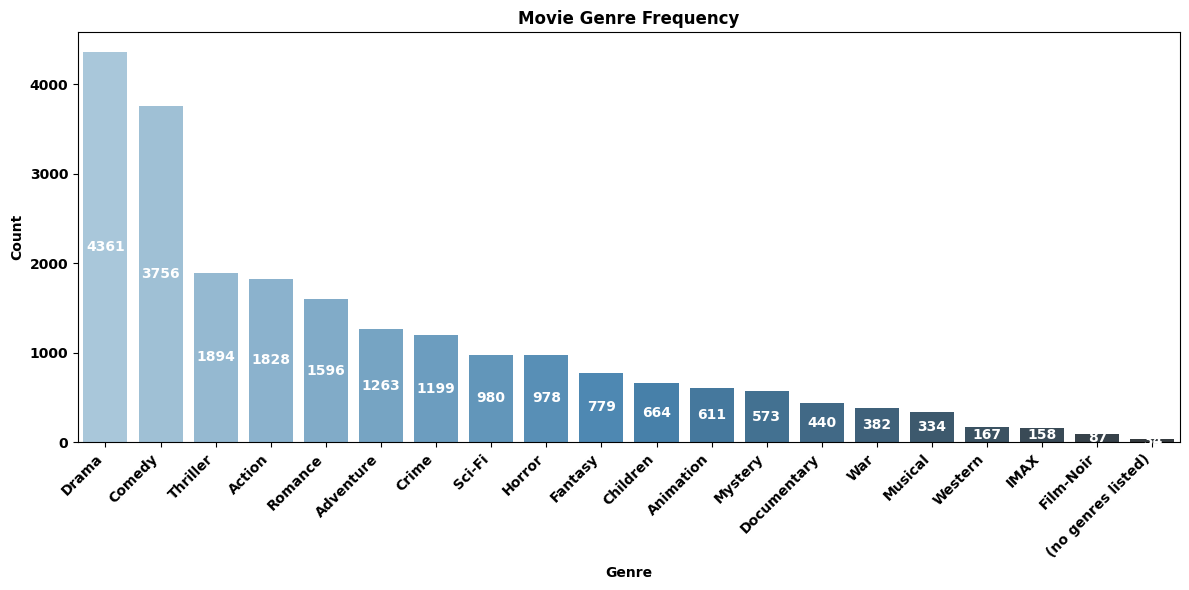

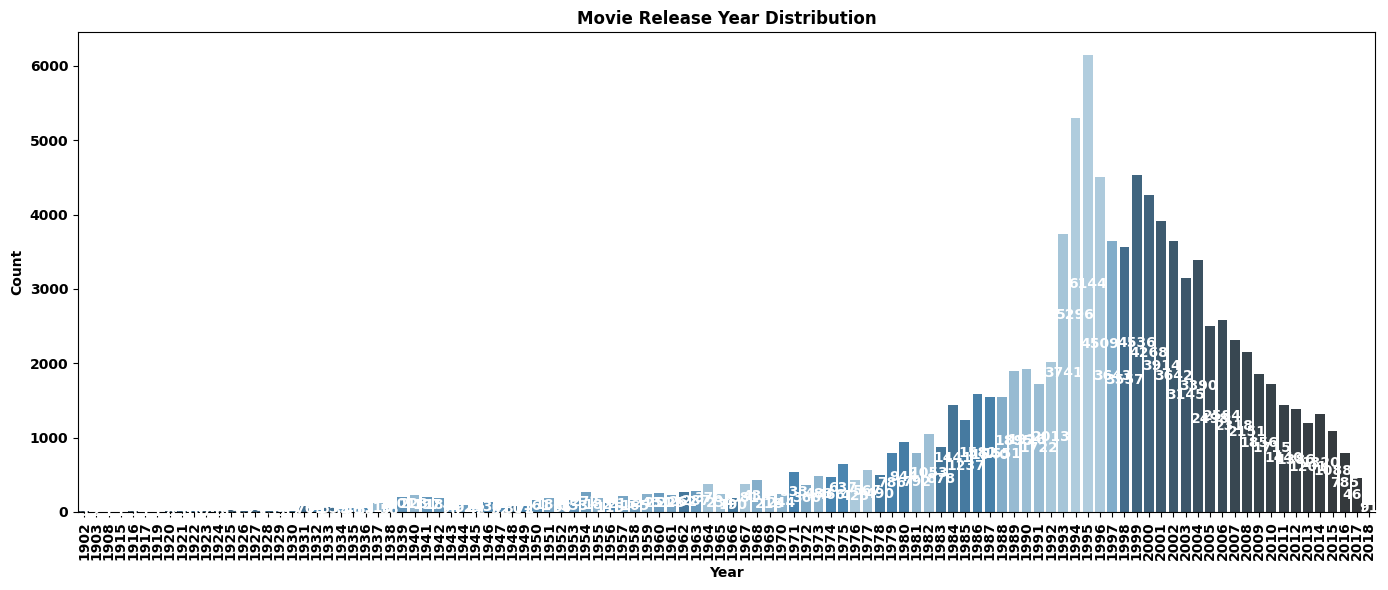

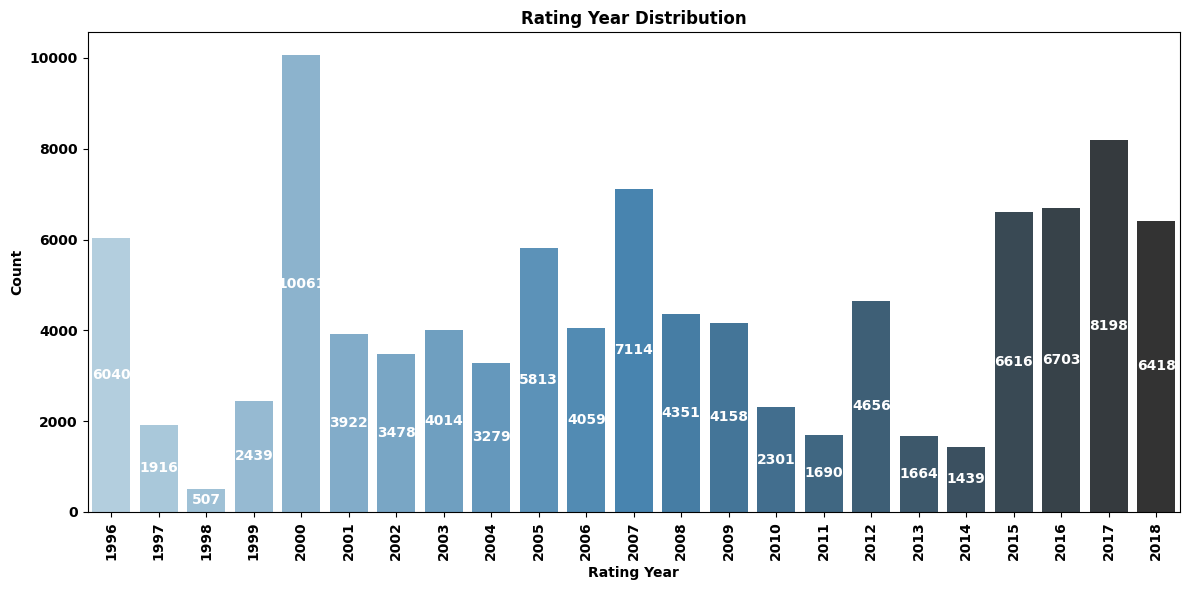

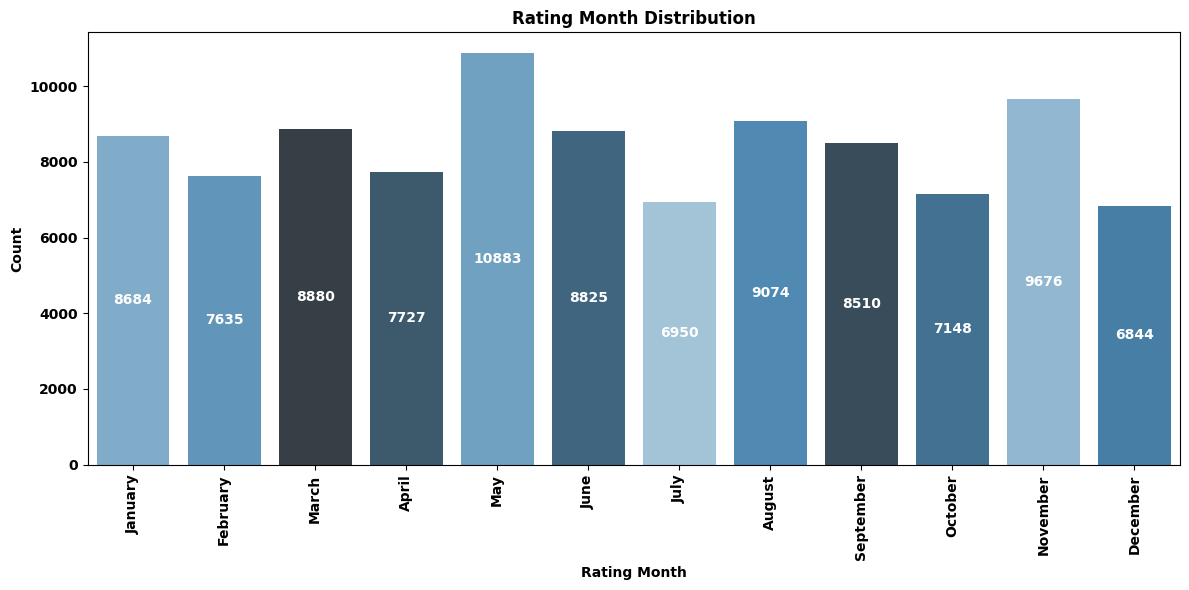

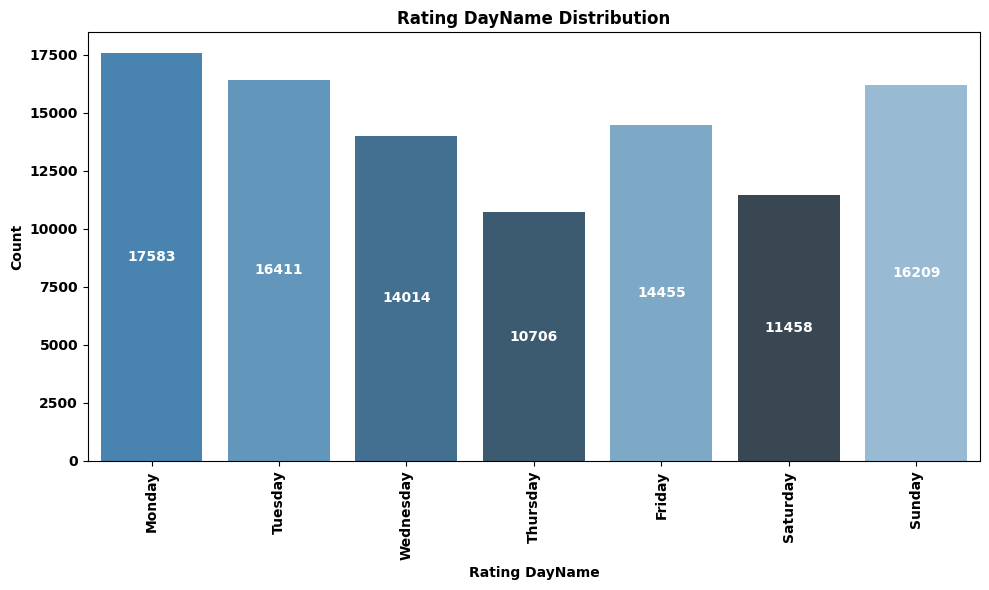

In [255]:
def DisplayBarPlot(df_Target, x_axis, y_axis, plot_title):
    # Plot
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=x_axis, 
                     y=y_axis, 
                     data=df_Target, 
                     hue=x_axis, 
                     palette='Blues_d', 
                     legend=False)

    # Bold title and axis labels
    plt.title(plot_title, fontweight='bold')
    plt.xlabel('Genre', fontweight='bold')
    plt.ylabel('Count', fontweight='bold')

    # Bold tick labels
    plt.xticks(rotation=45, ha='right', fontweight='bold')
    plt.yticks(fontweight='bold')

    # Add white count labels inside bars
    for container in ax.containers:
        ax.bar_label(container, color='white', fontweight='bold', label_type='center', fmt='%.0f')

    plt.tight_layout()
    plt.show()

def DisplayCountPlot(df_Target, x_axis, order, plot_title, fig_size, displayLabels=True):

    plt.figure(figsize=fig_size)
    ax = sns.countplot(x=x_axis, 
                       data=df_Target, 
                       order=order, 
                       hue=x_axis, 
                       palette='Blues_d', 
                       legend=False)

    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis, fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.xticks(rotation=90, fontweight='bold')
    plt.yticks(fontweight='bold')

    # Skip bar labels for Year (too many bars)
    if displayLabels == True:
        for container in ax.containers:
            ax.bar_label(container, color='white', fontweight='bold', label_type='center')

    plt.tight_layout()
    plt.show()

# Sort by count descending
df_Genres = df_Genres.sort_values('count', ascending=False)
DisplayBarPlot(df_Genres, 'genre', 'count', 'Movie Genre Frequency')

# Year (Movie Release Year)
yearOrder = df_Merged['Year'].value_counts().index.sort_values()
DisplayCountPlot(df_Merged, 'Year', yearOrder, 'Movie Release Year Distribution', (14,6))

# Rating Year
ratingYearOrder = sorted(df_Merged['Rating Year'].unique())
DisplayCountPlot(df_Merged, 'Rating Year', ratingYearOrder, 'Rating Year Distribution', (12,6))

# Rating Month
monthOrder = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
DisplayCountPlot(df_Merged, 'Rating Month', monthOrder, 'Rating Month Distribution', (12,6))

# Rating DayName
dayOrder = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DisplayCountPlot(df_Merged, 'Rating DayName', dayOrder, 'Rating DayName Distribution', (10,6))


##### **Refined Display Count Plots** #####
    After examining some of the initial plots, they appear to be too busy.
    It's in our best interest to try binning some of the data to make the plots clearer
    and give a clearer view into possible trends.

    NOTE:: Some of the Movie Titles DID NOT INCLUDE Release Year, which is why we are seeing <NA>s plotted

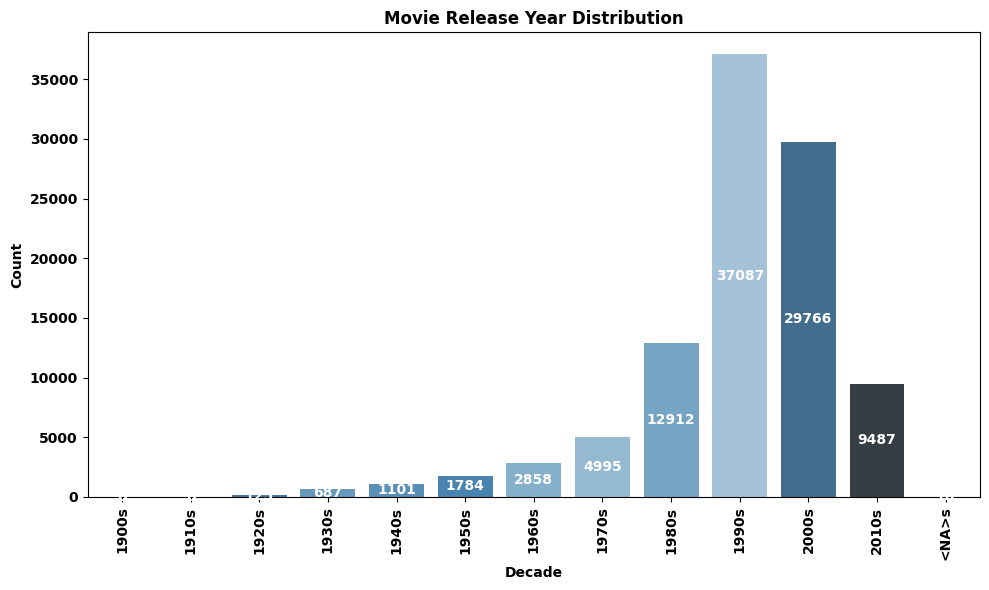

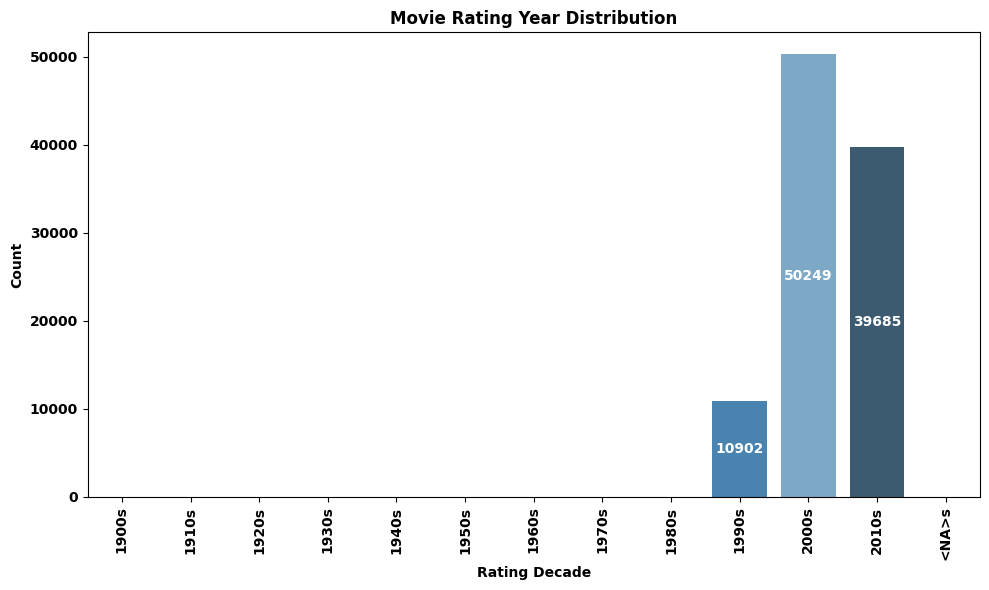

In [256]:
# Bin/Plot Movie Release Years by decades
df_BinnedYears = df_Merged.copy(deep=True)
df_BinnedYears['Decade'] = (df_BinnedYears['Year'].astype(float) // 10 * 10).astype('Int64').astype(str) + 's'

# Check value counts including NaN category
#print(df_Merged[df_Merged['Year'].isna()][['MovieId','Title', 'Year']])
#PrintDataFrameStatistics(df_BinnedYears)

decadesOrder = df_BinnedYears['Decade'].value_counts().index.sort_values()
DisplayCountPlot(df_BinnedYears, 'Decade', decadesOrder, 'Movie Release Year Distribution', (10,6))

# Bin/Plot Movie Review Years
df_BinnedYears['Rating Decade'] = (df_BinnedYears['Rating Year'].astype(float) // 10 * 10).astype('Int64').astype(str) + 's'
DisplayCountPlot(df_BinnedYears, 'Rating Decade', decadesOrder, 'Movie Rating Year Distribution', (10,6))

##### **Display Plot Observations** #####
    - Most of the movies in the dataset were released between 1990s - 2010s
    - All of the movies reviewed/reviewed were between 1990s - 2010s

##### **Examine Ratings per Users** #####

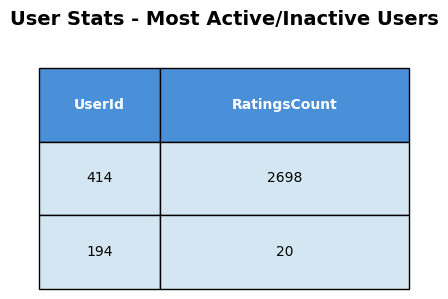

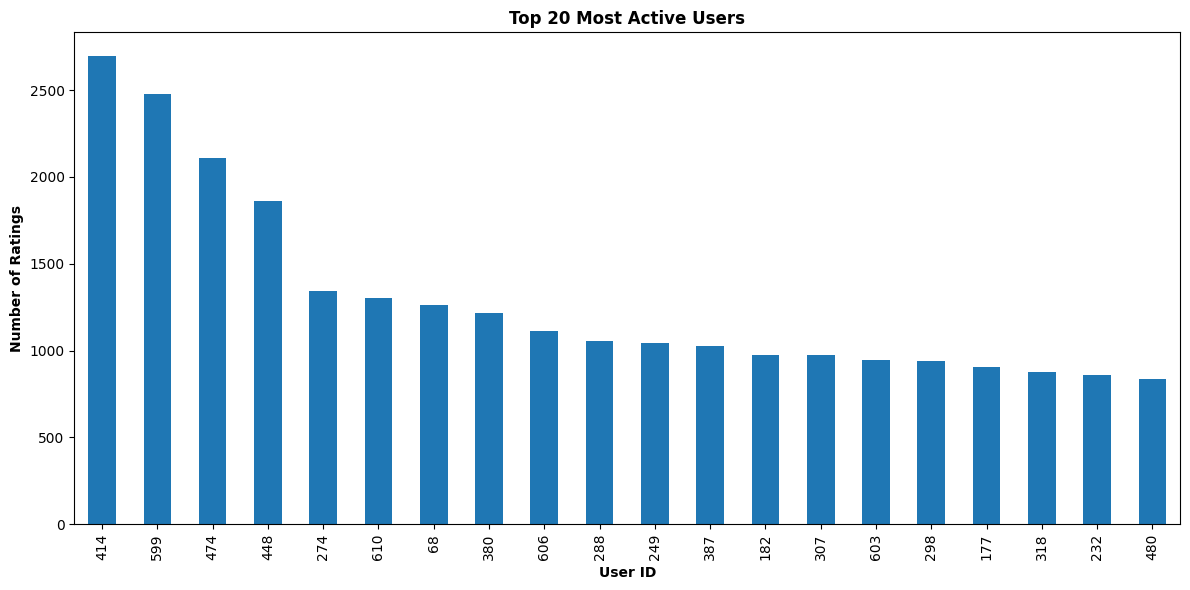

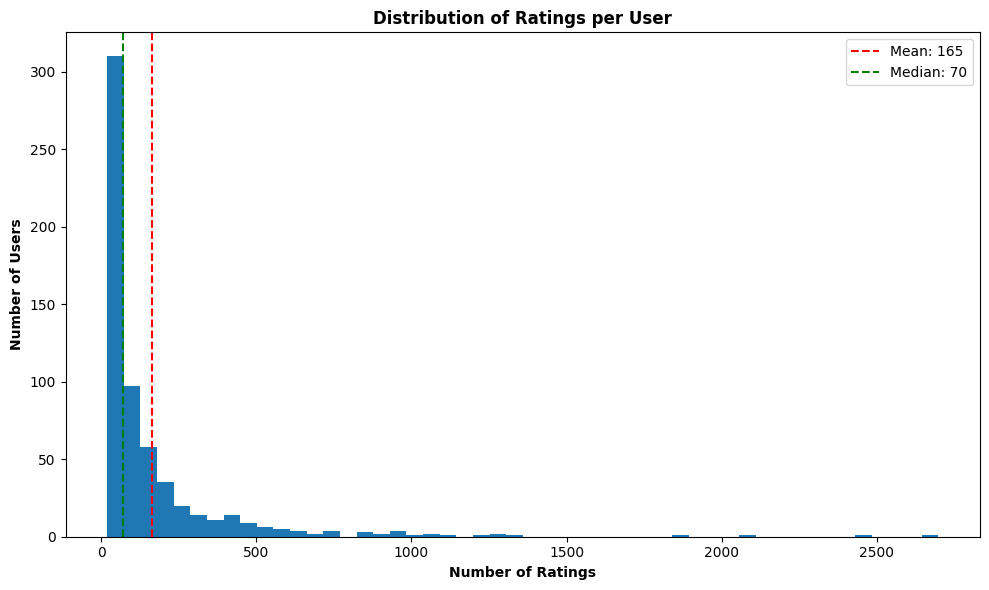

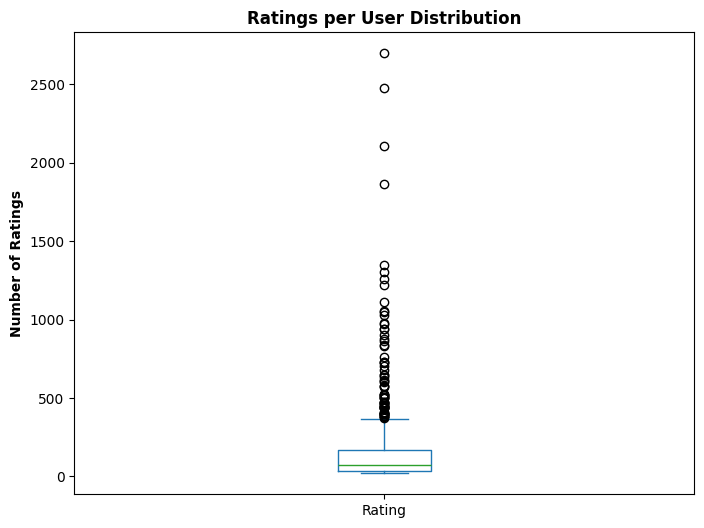

In [257]:
# Count the Ratings per user -- panda series
ratingsPerUser = df_Merged.groupby('UserId')['Rating'].count().sort_values(ascending=False)
# print('Ratings Per User Sample')
# print(ratingsPerUser.head(20))

# Most active/inactive user
df_UserStats = pd.DataFrame({
                                'UserId': [ratingsPerUser.idxmax(), ratingsPerUser.idxmin()],
                                'RatingsCount': [ratingsPerUser.max(), ratingsPerUser.min()]
                            }, index=['Most Active', 'Least Active'])

DisplayTable(df_UserStats, table_title='User Stats - Most Active/Inactive Users')

ratingsPerUser.head(20).plot(kind='bar', figsize=(12, 6))
plt.title('Top 20 Most Active Users', fontweight='bold')
plt.xlabel('User ID', fontweight='bold')
plt.ylabel('Number of Ratings', fontweight='bold')
plt.tight_layout()
plt.show()


# Histogram
plt.figure(figsize=(10, 6))
plt.hist(ratingsPerUser.values, bins='auto')
plt.axvline(ratingsPerUser.mean(), color='red', linestyle='--', label=f'Mean: {ratingsPerUser.mean():.0f}')
plt.axvline(ratingsPerUser.median(), color='green', linestyle='--', label=f'Median: {ratingsPerUser.median():.0f}')
plt.title('Distribution of Ratings per User', fontweight='bold')
plt.xlabel('Number of Ratings', fontweight='bold')
plt.ylabel('Number of Users', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


# Box Plot
ratingsPerUser.plot(kind='box', figsize=(8, 6))
plt.title('Ratings per User Distribution', fontweight='bold')
plt.ylabel('Number of Ratings', fontweight='bold')
plt.show()

print()
print()

##### **Ratings per Users Observations** #####
    - Number of ratings per user Mean: 165
    - Number of ratings per user Median: 70
    - Definite right skewed distribution
    - Most users had less than 165 ratings

##### **Examine Numerical Feature Distributions** #####

c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


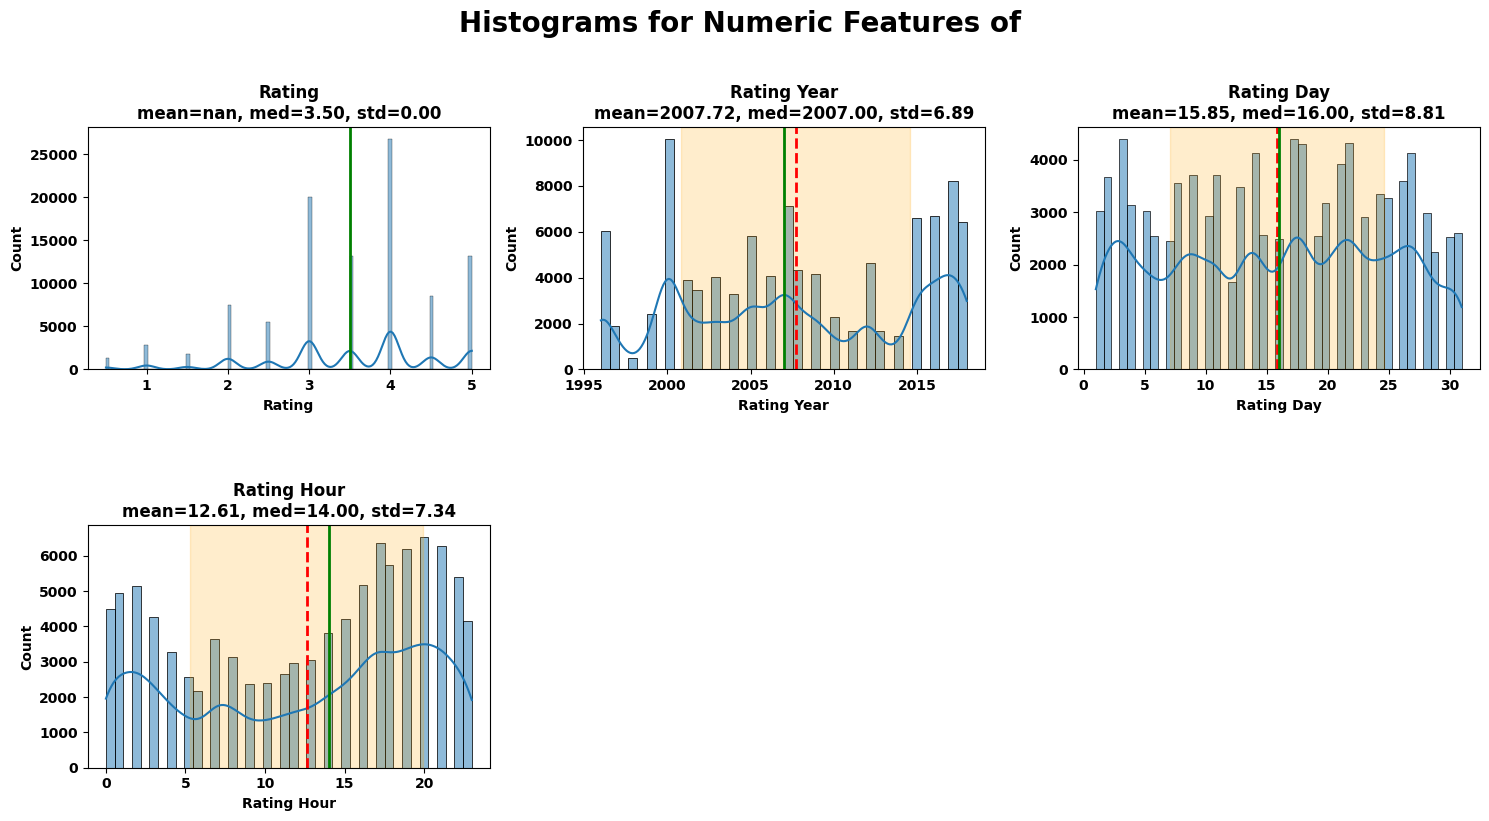

In [258]:
def DisplayNumericFeatureHistograms(df_target, feature_columns = None, target_label=None, plot_title=None, display_statistics=True):

    cols_to_plot = []
    statistics = []
    
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3 column plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    # Iterate over each numeric column and plot a historbram
    for i, col in enumerate(cols_to_plot):

        sns.histplot(data=df_target, x=col, ax=axes[i], kde=True)

        axes[i].set_xlabel(col, fontweight='bold')
        axes[i].set_ylabel('Count', fontweight='bold')
        data = df_target[col]

        if display_statistics == True:

            min_val = data.min()
            max_val = data.max()
            range_val = data.max() - data.min()
            mean_val = data.mean()
            median_val = data.median()
            mode_val = data.mode().tolist()
            std_val = data.std()
            quantile_val = data.quantile([0.25, 0.5, 0.75, 0.90, 0.95]).tolist()
            skew_val = data.skew()
            kurtosis_val = data.kurtosis()

            stats = {
                'Feature': col,
                'Min': min_val,
                'Max': max_val,
                'Mean': mean_val,
                'Median': median_val,
                'Mode': mode_val,
                'Std': std_val,
                'Range': range_val,
                'Quantile': quantile_val,
                'Skew': skew_val,
                'Kurtosis': kurtosis_val
            }            

            statistics.append(stats)

            # print(f'Min Value: {min_val:.3f}')
            # print(f'Max Value: {max_val:.3f}')
            # print(f'Mean Value: {mean_val:.3f}')
            # print(f'Median Value: {median_val:.3f}')
            # print(f'Mode Value: {mode_val}')
            # print(f'Standard Deviation: {std_val:.3f}')
            # print(f'Range Value = {range_val:.3f}')
            # print(f'Quantile Value = {quantile_val}')
            # print(f'Skew Value: {skew_val:.3f}')
            # print(f'Kurtosis Value: {kurtosis_val:.3f}')            

            axes[i].set_title(f'{col}\nmean={mean_val:.2f}, med={median_val:.2f}, std={data.std():.2f}', fontweight='bold')

            # Vertical lines for mean and median, shaded std
            axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
            axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')            
            axes[i].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='orange', label=f'±1 Std')

        else:
            axes[i].set_title(f'{col}', fontweight='bold')
        
        # Tick labels in bold
        axes[i].tick_params(axis='both', labelsize=10)
        for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            label.set_fontweight('bold')

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])

    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Histograms for Numeric Features of {data_set_name}'

    plt.suptitle(f'Histograms for Numeric Features of {data_set_name}', y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout(h_pad=5)
    plt.show()  

    print()
    print()

DisplayNumericFeatureHistograms(df_Merged, 
                                feature_columns=['Rating', 'Rating Year', 'Rating Day', 'Rating Hour'],
                                plot_title = 'Ratings Distribution', 
                                display_statistics=True)

##### **Numerical Feature Distribution Observations** #####
    - Ratings tend to be more positive than negative
    - Most Ratings were between 3 and 4
    - Most Ratings occurred 2000 and 2015 - bias of when dataset was created
    - Day of rating pretty evenly distributed
    - Most ratings occurred in the afternoon/evening

#### **Create User-Item Matrix** ####
    - Create pivot table to hold User-Item Matrix

***********************************
Description Stats
***********************************

                                   Title  count      mean       std  min  \
0                                    '71    1.0  4.000000       NaN  4.0   
1       'Hellboy': The Seeds of Creation    1.0  4.000000       NaN  4.0   
2                        'Round Midnight    2.0  3.500000  0.000000  3.5   
3                           'Salem's Lot    1.0  5.000000       NaN  5.0   
4                     'Til There Was You    2.0  4.000000  1.414214  3.0   
...                                  ...    ...       ...       ...  ...   
9441                            eXistenZ   22.0  3.863636  0.804479  2.0   
9442                                 xXx   24.0  2.770833  0.966607  0.5   
9443             xXx: State of the Union    5.0  2.000000  0.500000  1.5   
9444                      ¡Three Amigos!   26.0  3.134615  0.944009  1.0   
9445  À nous la liberté (Freedom for Us)    1.0  1.000000       NaN  1.0 

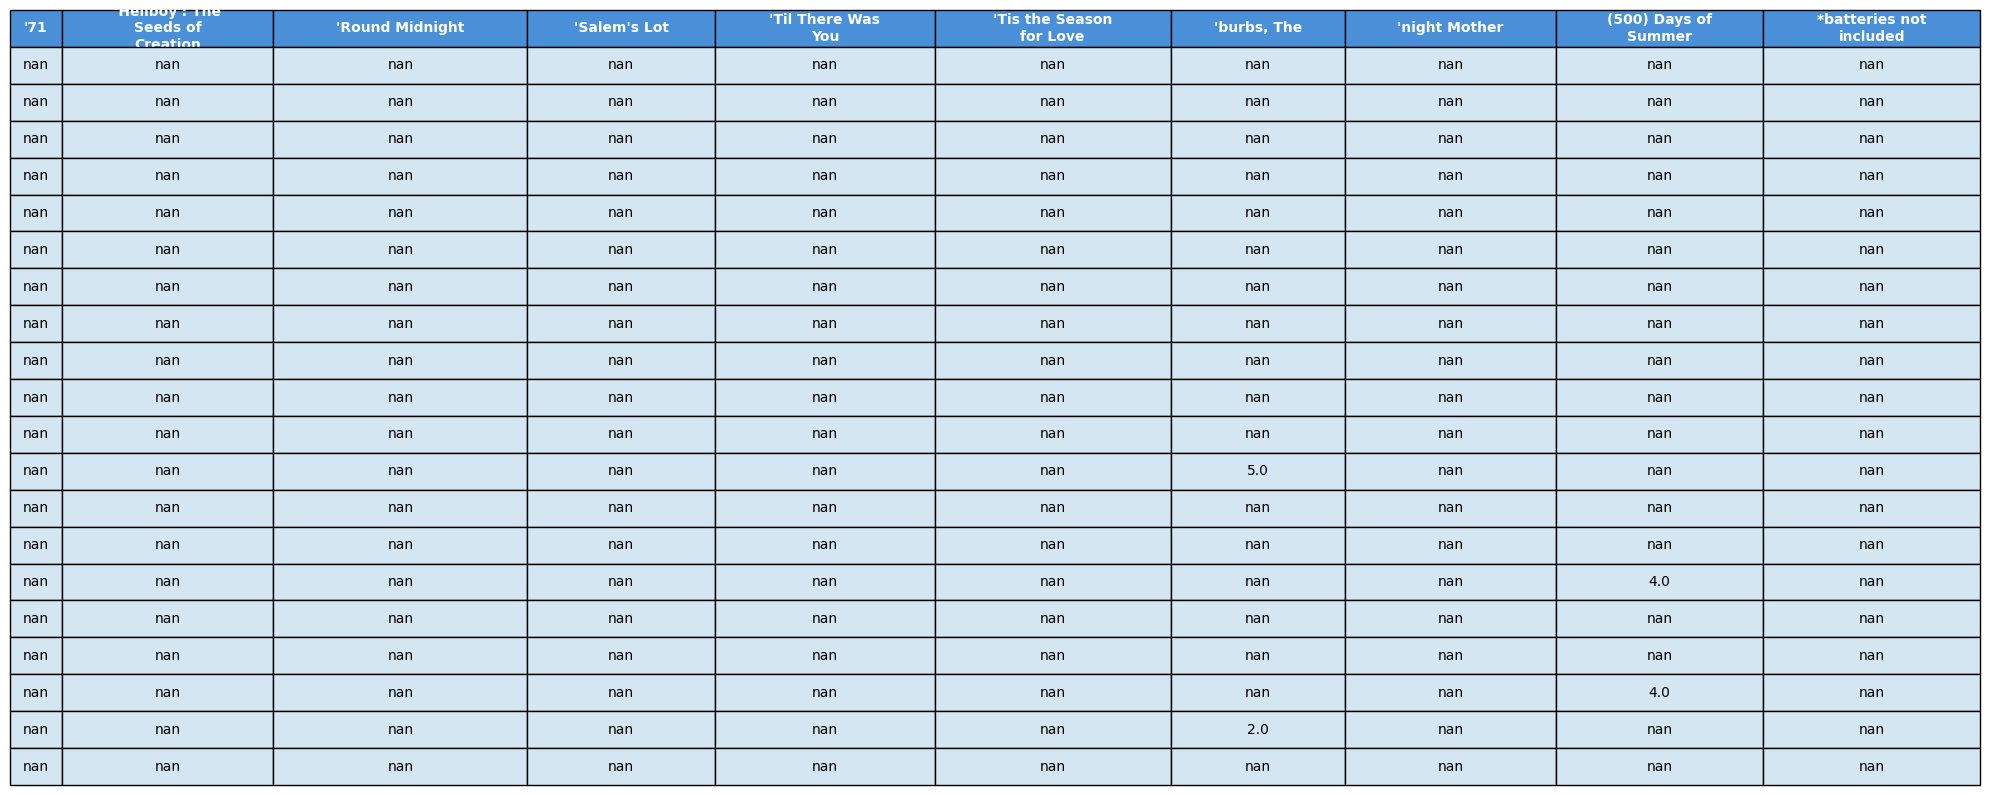




Imputed User-Item Matrix


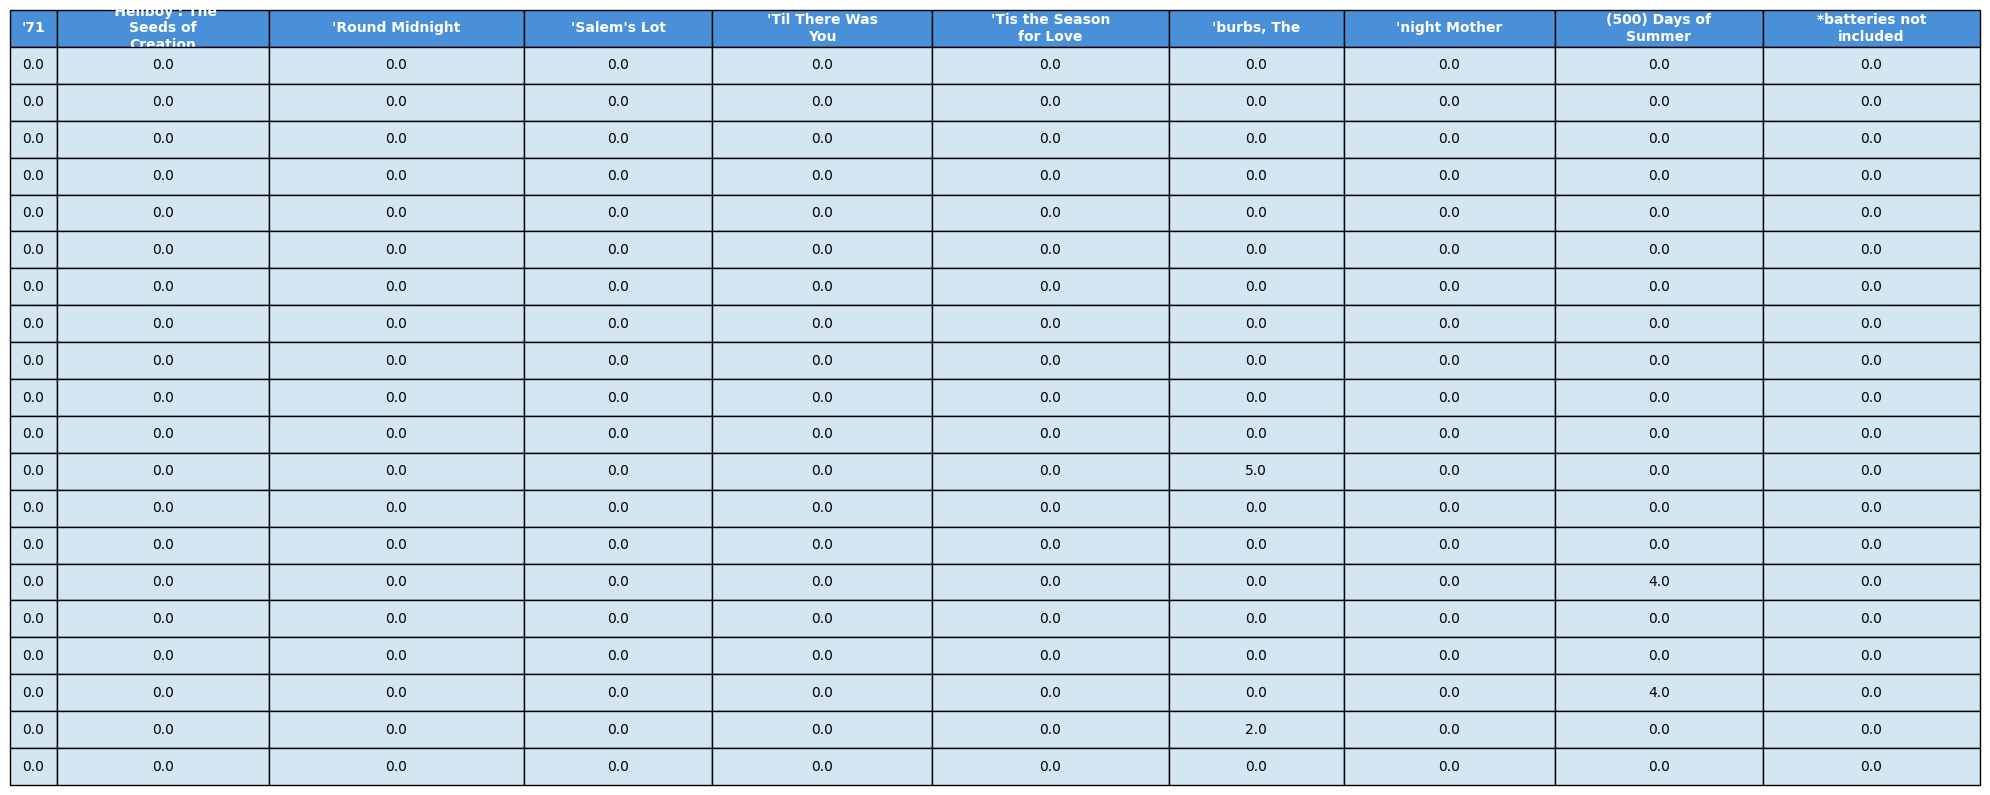

In [259]:
df_UserItemMatrix = df_Merged.pivot_table(index='UserId', columns='Title', values='Rating')
PrintDataFrameStatistics(df_UserItemMatrix, display_table=False)

df_UserItemMatrix_ForDisplay = df_UserItemMatrix.iloc[:20, :10]
DisplayTable(df_UserItemMatrix_ForDisplay)
print()

# Impute empty/NaN values with 0
df_UserItemMatrix.fillna(0, inplace=True)

print('Imputed User-Item Matrix')
df_UserItemMatrix_ForDisplay = df_UserItemMatrix.iloc[:20, :10]
DisplayTable(df_UserItemMatrix_ForDisplay)
print()

## **Task 3: Memory Based Collaborative Filtering** ##

#### **User-User Matrix via Cosine Similarities** ####

In [260]:
# Cosine Similarity
userCosineSimilarity = cosine_similarity(df_UserItemMatrix)
df_UserCosineSimilarity = pd.DataFrame(
                                            userCosineSimilarity,
                                            index=df_UserItemMatrix.index,
                                            columns=df_UserItemMatrix.index
                                        )

print('User Cosine similarity matrix shape:', df_UserCosineSimilarity.shape)
df_UserCosineSimilarity.head(20)

User Cosine similarity matrix shape: (610, 610)


UserId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
UserId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027433,0.060048,0.195461,0.129788,0.128855,0.156882,0.137720,0.064616,0.016968,...,0.080996,0.165357,0.222414,0.071056,0.155099,0.167947,0.270867,0.294153,0.094085,0.150053
2,0.027433,1.000000,0.000000,0.003726,0.016614,0.025333,0.027713,0.027257,0.000000,0.067445,...,0.223299,0.016866,0.012020,0.000000,0.000000,0.028564,0.012948,0.046926,0.027565,0.102624
3,0.060048,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.005048,0.004892,0.025041,0.000000,0.010738,0.013055,0.019247,0.021234,0.000000,0.032181
4,0.195461,0.003726,0.002251,1.000000,0.128659,0.092718,0.115652,0.062969,0.011361,0.031163,...,0.085938,0.134839,0.308497,0.052985,0.084930,0.203157,0.131746,0.150605,0.032198,0.107891
5,0.129788,0.016614,0.005020,0.128659,1.000000,0.300349,0.108842,0.429075,0.000000,0.030611,...,0.068048,0.418747,0.110364,0.258773,0.149366,0.107667,0.152866,0.136211,0.261232,0.060909
6,0.128855,0.025333,0.003936,0.092718,0.300349,1.000000,0.076193,0.370488,0.013904,0.020385,...,0.021415,0.448927,0.100414,0.396582,0.104968,0.103526,0.169527,0.179700,0.214234,0.053460
7,0.156882,0.027713,0.000000,0.115652,0.108842,0.076193,1.000000,0.115416,0.122072,0.132710,...,0.207358,0.125760,0.103212,0.062312,0.221501,0.201913,0.182605,0.324108,0.091260,0.195171
8,0.137720,0.027257,0.004941,0.062969,0.429075,0.370488,0.115416,1.000000,0.000000,0.023914,...,0.080203,0.550552,0.101324,0.324495,0.120916,0.099860,0.185142,0.188166,0.423993,0.078304
9,0.064616,0.000000,0.000000,0.011361,0.000000,0.013904,0.122072,0.000000,1.000000,0.040959,...,0.081138,0.009257,0.044355,0.018969,0.097186,0.076258,0.011844,0.100935,0.000000,0.074543


#### **User-User Matrix via Pearson Similarities** ####

In [261]:
# Pearson Similarity — keep NaN, let .corr() handle it
df_UserPearsonSimilarity = df_UserItemMatrix.T.corr(method='pearson')

print('User Pearson similarity matrix shape:', df_UserPearsonSimilarity.shape)
df_UserPearsonSimilarity.head(20)

User Pearson similarity matrix shape: (610, 610)


UserId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
UserId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.019364,0.053227,0.177592,0.121383,0.104575,0.141560,0.129102,0.055410,-0.000612,...,0.066363,0.150511,0.187209,0.056587,0.135557,0.125178,0.255344,0.264889,0.085757,0.102785
2,0.019364,1.000000,-0.002671,-0.004029,0.013082,0.015985,0.021526,0.023647,-0.003550,0.061715,...,0.219195,0.010710,-0.004468,-0.005503,-0.008115,0.010988,0.005600,0.033113,0.024279,0.089145
3,0.053227,-0.002671,1.000000,-0.004758,0.001795,-0.004831,-0.005792,0.001607,-0.003202,-0.005665,...,0.000005,-0.000747,0.010863,-0.004965,0.003548,-0.003608,0.012695,0.007858,-0.003050,0.015544
4,0.177592,-0.004029,-0.004758,1.000000,0.120791,0.069371,0.100732,0.053975,0.002150,0.015150,...,0.072457,0.120547,0.281645,0.039302,0.065368,0.166814,0.114619,0.116748,0.023684,0.061381
5,0.121383,0.013082,0.001795,0.120791,1.000000,0.293952,0.102043,0.426502,-0.004309,0.023259,...,0.061730,0.414818,0.095189,0.253979,0.141496,0.091018,0.145553,0.122951,0.258202,0.039885
6,0.104575,0.015985,-0.004831,0.069371,0.293952,1.000000,0.056715,0.365029,0.002413,0.000076,...,0.003259,0.438362,0.050410,0.386805,0.080984,0.047550,0.149099,0.137781,0.206912,-0.011451
7,0.141560,0.021526,-0.005792,0.100732,0.102043,0.056715,1.000000,0.108431,0.115482,0.120900,...,0.197708,0.113829,0.071878,0.051130,0.207905,0.173799,0.169364,0.305558,0.084739,0.165055
8,0.129102,0.023647,0.001607,0.053975,0.426502,0.365029,0.108431,1.000000,-0.004454,0.016250,...,0.073758,0.547616,0.085010,0.320004,0.112355,0.081935,0.177925,0.176561,0.421557,0.057729
9,0.055410,-0.003550,-0.003202,0.002150,-0.004309,0.002413,0.115482,-0.004454,1.000000,0.033790,...,0.074997,0.001792,0.026101,0.012507,0.088738,0.057886,0.003001,0.086361,-0.004054,0.054844


#### **User Movie Ratings Predictor Functions** ####
Write a function to predict the Rating that a UserId (UID) might give for a given MovieId (MID)</br>
Rank order the similarity of UID to all other UserIds </br>
Predicted Rating = weighted avg. (based on similarity score) of k similar users' ratings of MID</br>

In [262]:
# User Movie Ratings Predictor

def UserMovieRatingPredictor(df_UserSimilarity, user_id, movie_id, numberOfRatings=50):

    # Similar Users
    userSimilarities = df_UserSimilarity.loc[user_id]

    # Drop user_id from series, order descending
    userSimilarities = userSimilarities.drop(user_id)
    userSimilarities.sort_values(ascending=False, inplace=True)

    # print(f'userSimilarity Type: {type(userSimilarities)}')
    # print(f'userSimilarity Length: {len(userSimilarities)}')
    # print(f'userSimilarity: {userSimilarities}')

    # Get Movie Title from ID
    movieTitle = df_Merged[df_Merged['MovieId'] == movie_id]['Title'].iloc[0]
    #print(f'MovieTitle: {movieTitle}')

    # Find how Similar Users rated movie for users that rated the movie
    usersThatRatedMovie = df_UserItemMatrix[movieTitle]
    usersThatRatedMovie.drop(user_id, inplace=True)
    usersThatRatedMovie.dropna(inplace=True)
    # print(f'Number of Users who rated movie: {len(usersThatRatedMovie)}')
    # print(usersThatRatedMovie.head(20))

    usersThatRatedMovieSimilarities = userSimilarities[usersThatRatedMovie.index]

    # Top 50
    usersThatRatedMovieSimilarities.sort_values(ascending=False, inplace=True)
    usersThatRatedMovieSimilarities = usersThatRatedMovieSimilarities.head(numberOfRatings)
    # print(f'userSimilarity Length: {len(usersThatRatedMovieSimilarities)}')
    # print(f'userSimilarity: {usersThatRatedMovieSimilarities}')

    # Get ratings from top K similar users
    topRankings = usersThatRatedMovie[usersThatRatedMovieSimilarities.index]

    weightedSum = (usersThatRatedMovieSimilarities * topRankings).sum()
    similaritySum = usersThatRatedMovieSimilarities.sum()

    predictedMovieRating = weightedSum / similaritySum
    #print(f'PredictMovieRating is {predictedMovieRating}')

    return predictedMovieRating, usersThatRatedMovieSimilarities

# Cosine Movie Ratings Predictor
def CosineUserMovieRatingPredictor(user_id, movie_id, numberOfRatings=50):
    return UserMovieRatingPredictor(df_UserCosineSimilarity, user_id, movie_id, numberOfRatings)

# Pearson Movie Ratings Predictor
def PearsonUserMovieRatingPredictor(user_id, movie_id, numberOfRatings=50):
    return UserMovieRatingPredictor(df_UserPearsonSimilarity, user_id, movie_id, numberOfRatings)

def CompareMovieRatings(user_id, movie_id, numberOfRatings=50):
    
    movieTitle = df_Merged[df_Merged['MovieId'] == movie_id]['Title'].iloc[0]
    cosineMovieRatingPrediction, cosineSimilarUserRatings = CosineUserMovieRatingPredictor(user_id, movie_id, numberOfRatings)
    pearsonMovieRatingPrediction, pearsonSimilarUserRatings = PearsonUserMovieRatingPredictor(user_id, movie_id, numberOfRatings)

    print('===============================================================================')
    print(f'Cosine Movie Rankings for MovieId: {movie_id} MovieTitle: {movieTitle} PredictedMovingRanking: {cosineMovieRatingPrediction}')
    print(f'Cosine Similar User Movie Ratings:')
    print(cosineSimilarUserRatings)
    print('-------------------------------------------------------------------------------')
    print(f'Predicted Pearson Movie Ratings for MovieId: {movie_id} MovieTitle: {movieTitle} PredictedMovingRanking: {pearsonMovieRatingPrediction}')
    print(f'Pearson Similar User Movie Ratings:')
    print(pearsonSimilarUserRatings)
    print('===============================================================================')


# Calling the Function
userId = 1
movieId = 32
CompareMovieRatings(userId, movieId)    

Cosine Movie Rankings for MovieId: 32 MovieTitle: Twelve Monkeys (a.k.a. 12 Monkeys) PredictedMovingRanking: 3.0790302753448486
Cosine Similar User Movie Ratings:
UserId
266    0.359369
313    0.353714
57     0.346927
368    0.346557
91     0.337481
288    0.333936
469    0.332700
39     0.331592
452    0.331223
590    0.327961
480    0.327210
19     0.325784
135    0.325749
45     0.325703
330    0.323868
217    0.322881
64     0.319922
561    0.319278
577    0.319060
597    0.315085
202    0.311079
226    0.309671
555    0.306600
328    0.303927
160    0.301646
239    0.299549
608    0.294153
600    0.291186
434    0.290192
354    0.288179
414    0.285667
599    0.285513
391    0.285151
96     0.284331
570    0.284075
234    0.278725
274    0.278174
307    0.276190
294    0.275536
493    0.273989
68     0.272515
425    0.272090
220    0.271802
198    0.270915
607    0.270867
380    0.267313
385    0.267173
182    0.266289
17     0.265808
219    0.263527
Name: 1, dtype: float32
------

#### **Item-Item Matrix via Cosine Similarities** ####

In [263]:
# Cosine Similarity
itemSimilarity = cosine_similarity(df_UserItemMatrix.T)
df_ItemCosineSimilarity = pd.DataFrame(
                                    itemSimilarity,
                                    index=df_UserItemMatrix.columns,
                                    columns=df_UserItemMatrix.columns
                                )

print('Item similarity matrix shape:', df_ItemCosineSimilarity.shape)
df_ItemCosineSimilarity.head(20)

Item similarity matrix shape: (9446, 9446)


Title,'71,'Hellboy': The Seeds of Creation,'Round Midnight,'Salem's Lot,'Til There Was You,'Tis the Season for Love,"'burbs, The",'night Mother,(500) Days of Summer,*batteries not included,...,Zulu,[REC],[REC]²,[REC]³ 3 Génesis,anohana: The Flower We Saw That Day - The Movie,eXistenZ,xXx,xXx: State of the Union,¡Three Amigos!,À nous la liberté (Freedom for Us)
Title,,,,,,,,,,,,,,,,,,,,,
'71,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.141653,0.000000,...,0.000000,0.342055,0.543305,0.707107,0.0,0.000000,0.139431,0.327327,0.000000,0.0
'Hellboy': The Seeds of Creation,0.000000,1.000000,0.707107,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0
'Round Midnight,0.000000,0.707107,1.000000,0.000000,0.000000,0.000000,0.176777,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0
'Salem's Lot,0.000000,0.000000,0.000000,1.000000,0.857493,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0
'Til There Was You,0.000000,0.000000,0.000000,0.857493,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0
'Tis the Season for Love,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0
"'burbs, The",0.000000,0.000000,0.176777,0.000000,0.000000,0.000000,1.000000,0.071429,0.099735,0.248271,...,0.025566,0.000000,0.000000,0.000000,0.0,0.211467,0.089634,0.000000,0.372876,0.0
'night Mother,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.071429,1.000000,0.000000,0.000000,...,0.357930,0.000000,0.000000,0.000000,0.0,0.216295,0.000000,0.000000,0.180009,0.0
(500) Days of Summer,0.141653,0.000000,0.000000,0.000000,0.000000,0.000000,0.099735,0.000000,1.000000,0.155663,...,0.018108,0.149685,0.076961,0.100164,0.0,0.097935,0.276512,0.156764,0.169385,0.0


#### **Item-Item Matrix via Pearson Similarities** ####

In [264]:
# Pearson Similarity — keep NaN, let .corr() handle it
df_ItemPearsonSimilarity = df_UserItemMatrix.corr(method='pearson')

print('User Pearson similarity matrix shape:', df_ItemPearsonSimilarity.shape)
df_ItemPearsonSimilarity.head(20)

User Pearson similarity matrix shape: (9446, 9446)


Title,'71,'Hellboy': The Seeds of Creation,'Round Midnight,'Salem's Lot,'Til There Was You,'Tis the Season for Love,"'burbs, The",'night Mother,(500) Days of Summer,*batteries not included,...,Zulu,[REC],[REC]²,[REC]³ 3 Génesis,anohana: The Flower We Saw That Day - The Movie,eXistenZ,xXx,xXx: State of the Union,¡Three Amigos!,À nous la liberté (Freedom for Us)
Title,,,,,,,,,,,,,,,,,,,,,
'71,1.000000,-0.001642,-0.002324,-0.001642,-0.002254,-0.001642,-0.006407,-0.001642,0.135943,-0.004325,...,-0.003438,0.339935,0.542247,0.706526,-0.001642,-0.007675,0.134327,0.325287,-0.008185,-0.001642
'Hellboy': The Seeds of Creation,-0.001642,1.000000,0.706526,-0.001642,-0.002254,-0.001642,-0.006407,-0.001642,-0.010568,-0.004325,...,-0.003438,-0.004589,-0.002808,-0.002324,-0.001642,-0.007675,-0.007744,-0.003594,-0.008185,-0.001642
'Round Midnight,-0.002324,0.706526,1.000000,-0.002324,-0.003191,-0.002324,0.170199,-0.002324,-0.014958,-0.006121,...,-0.004866,-0.006495,-0.003975,-0.003289,-0.002324,-0.010863,-0.010961,-0.005087,-0.011585,-0.002324
'Salem's Lot,-0.001642,-0.001642,-0.002324,1.000000,0.857269,-0.001642,-0.006407,-0.001642,-0.010568,-0.004325,...,-0.003438,-0.004589,-0.002808,-0.002324,-0.001642,-0.007675,-0.007744,-0.003594,-0.008185,-0.001642
'Til There Was You,-0.002254,-0.002254,-0.003191,0.857269,1.000000,-0.002254,-0.008797,-0.002254,-0.014510,-0.005938,...,-0.004720,-0.006301,-0.003856,-0.003191,-0.002254,-0.010538,-0.010632,-0.004935,-0.011238,-0.002254
'Tis the Season for Love,-0.001642,-0.001642,-0.002324,-0.001642,-0.002254,1.000000,-0.006407,-0.001642,-0.010568,-0.004325,...,-0.003438,-0.004589,-0.002808,-0.002324,-0.001642,-0.007675,-0.007744,-0.003594,-0.008185,-0.001642
"'burbs, The",-0.006407,-0.006407,0.170199,-0.006407,-0.008797,-0.006407,1.000000,0.065968,0.063117,0.235908,...,0.012563,-0.017905,-0.010957,-0.009068,-0.006407,0.187953,0.062174,-0.014025,0.353194,-0.006407
'night Mother,-0.001642,-0.001642,-0.002324,-0.001642,-0.002254,-0.001642,0.065968,1.000000,-0.010568,-0.004325,...,0.356073,-0.004589,-0.002808,-0.002324,-0.001642,0.212646,-0.007744,-0.003594,0.175610,-0.001642
(500) Days of Summer,0.135943,-0.010568,-0.014958,-0.010568,-0.014510,-0.010568,0.063117,-0.010568,1.000000,0.133949,...,-0.003346,0.126147,0.061652,0.088726,-0.010568,0.053614,0.241092,0.139511,0.125905,-0.010568


#### **Similar Movie Predictor Functions** ####
Write a function to predict the top-N most similar movies to MovieId (MID) based on all ratings</br>
Rank order the similarity of MID to all other movies</br>
Return the top-N most similar movies</br>


In [265]:
# Similar Movie Ratings Predictor

def SimilarMoviesPredictor(df_ItemsSimilarity, movie_id, numberOfRatings=50):

    # Movie Rating
    movieTitle = df_Merged[df_Merged['MovieId'] == movie_id]['Title'].iloc[0]
    print(f'Movie Title is {movieTitle}')
    
    movieSimilarities = df_ItemsSimilarity[movieTitle].drop(movieTitle).sort_values(ascending=False)

    print(movieSimilarities.head(50))

    return movieSimilarities.head(numberOfRatings)

# Cosine Similar Movies Predictor
def CosineSimilarMoviesPredictor(movie_id, numberOfRatings=50):
    return SimilarMoviesPredictor(df_ItemCosineSimilarity, movie_id, numberOfRatings)

# Pearson Similar Movies Predictor
def PearsonSimiliarMoviesPredictor(movie_id, numberOfRatings=50):
    return SimilarMoviesPredictor(df_ItemPearsonSimilarity, movie_id, numberOfRatings)

def CompareSimilarMoviePredictors(movie_id=None, movie_title=None, numberOfRatings=50):
    
    movieTitle = None
    if movie_id is not None:
        movieTitle = df_Merged[df_Merged['MovieId'] == movie_id]['Title'].iloc[0]
    else:
        if movie_title is None:
            print('Error!! Plese enter either a valid movieTitle or movieId')
            return
        
        movieTitle = df_Movies['title'].str.replace(r'\s*\(\d{4}\)$', '', regex=True)
        movie_id = df_Merged[df_Merged['Title'] == movie_id]['MovieId'].iloc[0]

    print(f'Movie Title is: {movieTitle}')
    cosineSimilarMovies = CosineSimilarMoviesPredictor(movie_id, numberOfRatings)
    pearsonSimilarMovies = PearsonSimiliarMoviesPredictor(movie_id, numberOfRatings)

    print('===============================================================================')
    print(f'Cosine Movie Rankings for MovieId: {movie_id} MovieTitle: {movieTitle}')
    print(f'Cosine Similar Movies based on Ratings:')
    print(cosineSimilarMovies)
    print('-------------------------------------------------------------------------------')
    print(f'Predicted Pearson Movie Ratings for MovieId: {movie_id} MovieTitle: {movieTitle}')
    print(f'Pearson Similar Movies based on Ratings:')
    print(pearsonSimilarMovies)
    print('===============================================================================')

    return

# Calling The Function
movieId = 32
print('--------------------------------------------')
print('Process Movie by MovieId')
CompareSimilarMoviePredictors(movie_id=movieId)
print('--------------------------------------------')
print()

movieTitle = 'Jurassic Park (1993)'
print('--------------------------------------------')
print('Process Movie by MovieTitle')
CompareSimilarMoviePredictors(movie_id=movieId)
print('--------------------------------------------')
print()


--------------------------------------------
Process Movie by MovieId
Movie Title is: Twelve Monkeys (a.k.a. 12 Monkeys)
Movie Title is Twelve Monkeys (a.k.a. 12 Monkeys)
Title
Pulp Fiction                                               0.567698
Terminator 2: Judgment Day                                 0.562213
Independence Day (a.k.a. ID4)                              0.559553
Seven (a.k.a. Se7en)                                       0.541790
Fargo                                                      0.534338
Fugitive, The                                              0.515143
Usual Suspects, The                                        0.513948
Jurassic Park                                              0.513883
Star Wars: Episode IV - A New Hope                         0.513144
Heat                                                       0.510677
Toy Story                                                  0.508593
Mission: Impossible                                        0.508549
Batman 

## **Task 4: Model Based Collaborative Filtering** ##
Test out the following algorithms on Merged_df DataFrame to Impute (Predict) the missing rating data. </br>
Ensure that each row's prediction and each model's prediction doesn't interfere with the others. </br>
    SVD</br>
    NMF</br>
    KNN</br>

##### **Impute Missing Values Using SVD** #####

In [ ]:
# UserItem Matrix from df_Merged
# UserItem Matrix already has NaN values replaced with 0s
df_FilledSVD = df_UserItemMatrix.copy(deep=True)

# Clean up Nans 1st
#df_FilledSVD = df_SVD.fillna(0)

# Perform SVD
k = 20
U, s, Vt = svds(df_FilledSVD.values, k=k)
s_diag = np.diag(s)

# Return predictions as NumPy array
svdPredictions = np.dot(np.dot(U, s_diag), Vt)

df_ImputedSVD = pd.DataFrame(svdPredictions,
                             index=df_UserItemMatrix.index,
                             columns=df_UserItemMatrix.columns)

print('SVD Impution Results')
print(df_ImputedSVD.sample(20))

SVD Impution Results
Title        '71  'Hellboy': The Seeds of Creation  'Round Midnight  \
UserId                                                                
448     0.053586                         -0.036163         0.001601   
296    -0.013849                          0.015510         0.010133   
257     0.004046                         -0.000289         0.000777   
346    -0.048346                          0.025052         0.027746   
514     0.118830                         -0.005134         0.007354   
153     0.000703                          0.008655         0.007684   
553    -0.026975                          0.022892         0.015355   
127    -0.004651                          0.000337         0.001108   
187     0.087685                          0.059519         0.060471   
147    -0.023328                         -0.002022        -0.000105   
508    -0.006169                         -0.000020         0.001294   
160    -0.060373                          0.025155      

##### **Impute Missing Values Using NMF** #####

In [ ]:
# UserItem Matrix from df_Merged
# UserItem Matrix already has NaN values replaced with 0s
df_FilledNMF = df_UserItemMatrix.copy(deep=True)

# Clean up Nans 1st
#df_FilledNMF = df_NMF.fillna(0)

# Perform NMF
model = NMF(n_components=20, max_iter=500, random_state=42)
W = model.fit_transform(df_FilledNMF)
H = model.components_

# Return predictions as NumPy array
nmfPredictions = np.dot(W, H)

df_ImputedNMF = pd.DataFrame(svdPredictions,
                             index=df_UserItemMatrix.index,
                             columns=df_UserItemMatrix.columns)

print('NMF Impution Results')
print(df_ImputedNMF.sample(20))

NMF Impution Results
Title        '71  'Hellboy': The Seeds of Creation  'Round Midnight  \
UserId                                                                
27     -0.012823                         -0.005146         0.005552   
359    -0.004034                          0.009340         0.006914   
194    -0.008956                         -0.000642         0.000316   
18     -0.183704                          0.061302         0.052227   
238    -0.005557                          0.004108         0.003204   
441    -0.017027                          0.014797         0.011957   
165     0.044328                          0.008712         0.004112   
240    -0.052877                         -0.019139        -0.009879   
180     0.004115                          0.005604         0.006708   
387    -0.139331                          0.074313         0.099867   
580    -0.014997                          0.080044         0.067113   
37      0.007280                          0.003375      

##### **Impute Missing Values Using KNN** #####

In [ ]:
# UserItem Matrix from df_Merged
df_KNN = df_Merged.pivot_table(index='UserId', columns='Title', values='Rating')

# KNN Imputer (imputes NaN directly) - initially 20; Try 5 neighbors??
model = KNNImputer(n_neighbors=20)
knnPredictions = model.fit_transform(df_KNN)

df_ImputedKNN = pd.DataFrame(knnPredictions,
                             index=df_UserItemMatrix.index,
                             columns=df_UserItemMatrix.columns)


print('KNN Impution Results')
print(df_ImputedKNN.sample(20))

print()

KNN Impution Results
Title   '71  'Hellboy': The Seeds of Creation  'Round Midnight  'Salem's Lot  \
UserId                                                                         
378     4.0                               4.0              3.5           5.0   
52      4.0                               4.0              3.5           5.0   
252     4.0                               4.0              3.5           5.0   
265     4.0                               4.0              3.5           5.0   
67      4.0                               4.0              3.5           5.0   
27      4.0                               4.0              3.5           5.0   
534     4.0                               4.0              3.5           5.0   
559     4.0                               4.0              3.5           5.0   
498     4.0                               4.0              3.5           5.0   
497     4.0                               4.0              3.5           5.0   
540     4.0        

In [274]:
# Check original matrix before KNN
print(f"Shape: {df_UserItemMatrix.shape}")
print(f"NaN count: {df_UserItemMatrix.isna().sum().sum()}")
print(f"Zero count: {(df_UserItemMatrix == 0).sum().sum()}")
print(f"Total cells: {df_UserItemMatrix.size}")
print(f"Sparsity: {df_UserItemMatrix.isna().sum().sum() / df_UserItemMatrix.size * 100:.2f}%")

# Find a movie with many ratings
rating_counts = df_UserItemMatrix.notna().sum()
top_movie = rating_counts.idxmax()
print(f"Most rated movie: {top_movie}")
print(f"Number of ratings: {rating_counts[top_movie]}")
print(f"Sample values: {df_UserItemMatrix[top_movie].dropna().head(10)}")


Shape: (610, 9446)
NaN count: 0
Zero count: 5661591
Total cells: 5762060
Sparsity: 0.00%
Most rated movie: '71
Number of ratings: 610
Sample values: UserId
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
Name: '71, dtype: float32
